# UCI Online Retail — Business Data Analysis

## Project Credits
- **Lead Data Analyst:** Abdeljalil El Khyati
- **Implementation Assistant:** Qwen.ai / ChatGPT 
- **Dataset:** UCI Machine Learning Repository — Online Retail (ID: 352)
- **License:** CC BY 4.0
- **Completion Date:** September 2026

## Project Objective
Analyze the UCI Online Retail dataset as if it were provided by a client who wants clear, evidence-based business insights.

The objective is not only to calculate statistics, but to:
- Understand the data
- Assess data quality
- Identify business patterns
- Investigate important questions
- Produce actionable recommendations
- Document assumptions, limitations, and analytical decisions

This notebook follows an iterative analytical workflow. Analytical branches may be activated, modified, or removed depending on the evidence found in previous stages.

## Methodology
**DATA → EVIDENCE → INTERPRETATION → ACTION**

Analytical statements are distinguished between:
- **Fact:** directly measured or calculated from the dataset
- **Interpretation:** a reasoned reading of an observed pattern
- **Hypothesis:** a plausible explanation requiring further validation
- **Recommendation:** a proposed business action

No causal claim is made from observational transactional data alone.

## Phase 0: Dataset Context & Source Description

### 1. Project Header & Objective
**Source:** UCI Machine Learning Repository — Online Retail (Dataset ID: 352)  
**License:** Creative Commons Attribution 4.0 International (CC BY 4.0)  
**Business Context:** The dataset concerns a UK-based and registered non-store online retail company. The company mainly sells unique all-occasion gifts, and the official UCI description states that many of its customers are wholesalers.  
**Timeframe:** Transactions occurring between 01/12/2010 and 09/12/2011.  
**Total Instances:** 541,909 transactions.

### 2. Expected Variables (According to UCI Official Documentation)
The official dataset documentation specifies **8 variables**:
1. `InvoiceNo` (ID): 6-digit integral number uniquely assigned to each transaction. Starts with 'C' if cancelled.
2. `StockCode` (ID): 5-digit integral number uniquely assigned to each distinct product.
3. `Description` (Feature): Product name.
4. `Quantity` (Feature): Quantities of each product per transaction.
5. `InvoiceDate` (Feature): Day and time when each transaction was generated.
6. `UnitPrice` (Feature): Product price per unit in sterling (£).
7. `CustomerID` (Feature): 5-digit integral number uniquely assigned to each customer.
8. `Country` (Feature): Name of the country where each customer resides.

*Note: UCI documentation states "Has Missing Values: No". This claim is independently checked during the Data Quality Assessment phase.*

### 3. Analytical Principles
1. Understand before cleaning.
2. Inspect before transforming.
3. Every cleaning decision must have a documented reason.
4. Every important result must be validated.
5. Separate facts, interpretations, hypotheses, and recommendations.
6. Do not force an analytical branch if the data does not support it.
7. Prefer simple and readable code.
8. Use visualization only when it helps answer a business question.
9. Do not claim causality from observational data.
10. The workflow can change when new evidence appears.

### 4. Analytical Workflow
DATA

↓

DATA ACQUISITION

↓

INITIAL INSPECTION

↓

DATA QUALITY ASSESSMENT

↓

QUALITY DECISION

↓

CLEANING & PREPARATION

↓

VALIDATION

↓

EXPLORATORY DATA ANALYSIS

↓

QUESTION DISCOVERY

↓

TARGETED ANALYSIS

↓

FINDINGS

↓

RECOMMENDATIONS

↓

FINAL VALIDATION

↓

LIMITATIONS

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Set plotting style
sns.set_theme(style="whitegrid")

print("Environment setup complete.")

Environment setup complete.


# Phase 1: Data Acquisition
### 1. Fetch Data via UCI API

In [2]:
# Fetch data using the official UCI API (ID 352 = Online Retail)
from ucimlrepo import fetch_ucirepo

print("Fetching data from UCI Repository...")
retail_data = fetch_ucirepo(id=352)

# Extract the main dataframe
df = retail_data.data.features.copy()

print("Data loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Fetching data from UCI Repository...
Data loaded successfully.
Shape: (541909, 6)
Columns: ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### 2. Initial Inspection (head, shape, info, describe)

In [3]:
# 1. View first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# 2. Check dimensions
print("\n--- Dataset Shape ---")
print(df.shape)

# 3. Check data types and non-null counts
print("\n--- Data Information ---")
df.info()

# 4. Check descriptive statistics
print("\n--- Descriptive Statistics ---")
display(df.describe(include="all").T)

--- First 5 Rows ---


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom



--- Dataset Shape ---
(541909, 6)

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,218.08,"-80,995.00",1.00,3.00,10.00,"80,995.00"
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,96.76,"-11,062.06",1.25,2.08,4.13,"38,970.00"
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","1,713.60","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Initial Inspection — Findings

### Dataset Size
- Rows: 541,909
- Columns initially returned by `features`: 6
- The UCI documentation specifies 8 columns.
- `InvoiceNo` and `StockCode` are not included in the initial `features` dataframe.

### Columns and Data Types
- `Description`, `InvoiceDate`, `Country`: stored as `object`
- `Quantity`: stored as `int64`
- `UnitPrice`, `CustomerID`: stored as `float64`
- `InvoiceDate` requires conversion to `datetime` for time analysis.

### Initial Observations
- The dataset starts on 01/12/2010.
- The initial sample contains positive quantities and prices.
- Missing values are present in `CustomerID` and `Description`.

### Initial Questions
1. Where are `InvoiceNo` and `StockCode` stored within the `ucimlrepo` object?
2. Why does the retrieved data show missing values although the UCI metadata states no missing values?
3. What do the negative quantities and extreme prices represent?

These questions are investigated before any cleaning decision is made.

# Phase 2: Structural Investigation

### 2-1. Investigating Missing Columns

The initial API extraction returned only 6 columns instead of the 8 documented by UCI.

The missing identifiers are:
- `InvoiceNo`
- `StockCode`

Because `ucimlrepo` separates ID variables from feature variables, we inspect the internal structure of `retail_data.data` before continuing the analysis.

In [4]:
# 1. Check the keys inside the data dictionary
print("Keys in retail_data.data:")
print(retail_data.data.keys())

# 2. Check the variable metadata provided by UCI
print("\n--- Variables Metadata ---")
if hasattr(retail_data, 'variables'):
    display(retail_data.variables)
else:
    print("No variables metadata found.")

# 3. Compare the extracted features with the documented variables
print("\n--- Current Columns in Features ---")
print(df.columns.tolist())

Keys in retail_data.data:
dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

--- Variables Metadata ---


,name,role,type,demographic,description,units,missing_values
0,InvoiceNo,ID,Categorical,None,a 6-digit integral number uniquely assigned to...,None,no
1,StockCode,ID,Categorical,None,a 5-digit integral number uniquely assigned to...,None,no
2,Description,Feature,Categorical,None,product name,None,no
3,Quantity,Feature,Integer,None,the quantities of each product (item) per tran...,None,no
4,InvoiceDate,Feature,Date,None,the day and time when each transaction was gen...,None,no
5,UnitPrice,Feature,Continuous,None,product price per unit,sterling,no
6,CustomerID,Feature,Categorical,None,a 5-digit integral number uniquely assigned to...,None,no
7,Country,Feature,Categorical,None,the name of the country where each customer re...,None,no



--- Current Columns in Features ---
['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### 2-2. Reconstructing the Complete Dataset

The investigation confirms that `InvoiceNo` and `StockCode` are stored under the `ids` key in the UCI data object.

We therefore combine the `ids` dataframe with the `features` dataframe to reconstruct the complete 8-column dataset and verify the result against the official variable list.

In [5]:
# Extract IDs dataframe
ids_df = retail_data.data['ids']

print("Columns in IDs dataframe:")
print(ids_df.columns.tolist())
display(ids_df.head())

# Merge IDs with Features to reconstruct the complete dataset
print("\n--- Merging IDs and Features ---")
df_complete = pd.concat([ids_df, df], axis=1)

print("Complete dataset shape:", df_complete.shape)
print("Complete columns:", df_complete.columns.tolist())

# Verify that all 8 expected columns are present
expected_columns = [
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'CustomerID',
    'Country'
]

print("\n--- Verification ---")
print("Total columns:", len(df_complete.columns))
print("Expected columns:", expected_columns)
print("Match:", set(df_complete.columns) == set(expected_columns))

# Update df to be the complete dataframe
df = df_complete

print("\n✅ Dataset is now complete! Proceeding with analysis...")

Columns in IDs dataframe:
['InvoiceNo', 'StockCode']


,InvoiceNo,StockCode
0,536365,85123A
1,536365,71053
2,536365,84406B
3,536365,84029G
4,536365,84029E



--- Merging IDs and Features ---
Complete dataset shape: (541909, 8)
Complete columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

--- Verification ---
Total columns: 8
Expected columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Match: True

✅ Dataset is now complete! Proceeding with analysis...


## 2-3. Resolution: Reconstructing the Complete Dataset

### Problem Solved
The initial API extraction returned only 6 feature columns. Investigation of the `ucimlrepo` structure showed that `InvoiceNo` and `StockCode` are stored separately under the `ids` key.

### Action Taken
The `ids` dataframe was combined with the `features` dataframe using `pd.concat(..., axis=1)`.

### Updated Dataset Status
- **Rows:** 541,909
- **Columns:** 8
- **Verification:** All expected columns are present.

### Resolution
The complete analytical dataset now contains:
`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`.

# Phase 3: Data Quality Assessment

### 3-1. Quality Metrics (Missing, Duplicates, Cardinality)

In [6]:
# 1. Missing values count and percentage
print("--- Missing Values ---")
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

display(
    pd.DataFrame({
        'Count': missing_counts,
        'Percentage (%)': missing_pct
    })
)

# 2. Duplicate rows
print("\n--- Duplicates ---")
print("Total duplicate rows:", df.duplicated().sum())

# 3. Unique values per column
print("\n--- Unique Values ---")
display(df.nunique())

# 4. Check for cancellations
print("\n--- Cancellations Check ---")
cancellation_count = df["InvoiceNo"].astype(str).str.startswith("C").sum()
print("Invoices starting with 'C':", cancellation_count)

# 5. Negative quantities
print("\n--- Negative Quantities ---")
print("Rows with Quantity < 0:", (df["Quantity"] < 0).sum())

# 6. Zero or negative prices
print("\n--- Zero/Negative Prices ---")
print("Rows with UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

--- Missing Values ---


,Count,Percentage (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00



--- Duplicates ---
Total duplicate rows: 5268

--- Unique Values ---


InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


--- Cancellations Check ---
Invoices starting with 'C': 9288

--- Negative Quantities ---
Rows with Quantity < 0: 10624

--- Zero/Negative Prices ---
Rows with UnitPrice <= 0: 2517


### 3-2. Deep Investigation (Missing IDs, Outliers, Date Range)²

In [7]:
# 1. Investigate Missing CustomerID
print("--- Investigation: Missing CustomerID ---")

df_missing_id = df[df['CustomerID'].isna()]
df_has_id = df[df['CustomerID'].notna()]

print(f"Rows with Missing ID: {len(df_missing_id)}")
print(f"Rows with Valid ID: {len(df_has_id)}")

# Compare basic metrics
print("\nAverage Quantity (Missing ID vs Valid ID):")
print(f"Missing ID: {df_missing_id['Quantity'].mean():.2f}")
print(f"Valid ID: {df_has_id['Quantity'].mean():.2f}")

print("\nAverage UnitPrice (Missing ID vs Valid ID):")
print(f"Missing ID: {df_missing_id['UnitPrice'].mean():.2f}")
print(f"Valid ID: {df_has_id['UnitPrice'].mean():.2f}")

# Check cancellations among missing IDs
missing_cancellations = (
    df_missing_id['InvoiceNo']
    .astype(str)
    .str.startswith('C')
    .sum()
)

print(
    f"\nCancellations in Missing ID group: "
    f"{missing_cancellations} "
    f"({(missing_cancellations / len(df_missing_id) * 100):.2f}%)"
)

# 2. Investigate extreme values
print("\n--- Investigation: Extreme Values ---")

print("Top 5 Highest Quantities:")
display(
    df.nlargest(
        5,
        'Quantity'
    )[
        ['InvoiceNo', 'StockCode', 'Description',
         'Quantity', 'UnitPrice']
    ]
)

print("\nTop 5 Highest Unit Prices:")
display(
    df.nlargest(
        5,
        'UnitPrice'
    )[
        ['InvoiceNo', 'StockCode', 'Description',
         'Quantity', 'UnitPrice']
    ]
)

# 3. Check Date Range
print("\n--- Investigation: Date Range ---")
print("Earliest Date:", df['InvoiceDate'].min())
print("Latest Date:", df['InvoiceDate'].max())

--- Investigation: Missing CustomerID ---
Rows with Missing ID: 135080
Rows with Valid ID: 406829

Average Quantity (Missing ID vs Valid ID):
Missing ID: 2.00
Valid ID: 12.06

Average UnitPrice (Missing ID vs Valid ID):
Missing ID: 8.08
Valid ID: 3.46

Cancellations in Missing ID group: 383 (0.28%)

--- Investigation: Extreme Values ---
Top 5 Highest Quantities:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00
74614,542504,37413,NaN,5568,0.00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21



Top 5 Highest Unit Prices:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
222681,C556445,M,Manual,-1,"38,970.00"
524602,C580605,AMAZONFEE,AMAZON FEE,-1,"17,836.46"
43702,C540117,AMAZONFEE,AMAZON FEE,-1,"16,888.02"
43703,C540118,AMAZONFEE,AMAZON FEE,-1,"16,453.71"
15016,C537630,AMAZONFEE,AMAZON FEE,-1,"13,541.33"



--- Investigation: Date Range ---
Earliest Date: 1/10/2011 10:04
Latest Date: 9/9/2011 9:52


Based on the quantitative investigation, the following analytical decisions were established.

### 3-3. Quality Decisions Matrix

| Issue | Records Affected | Evidence & Interpretation | Decision |
|---|---:|---|---|
| **Missing `CustomerID`** | 135,080 (24.93%) | Missing customer identifiers affect customer-level analysis. The transactions remain useful for aggregate sales analysis because they contain revenue-related fields. | **Retain** for sales analysis and label as `"Unknown"`; exclude from customer-level RFM and concentration analysis. |
| **Extreme High Quantities** | Includes a 80,995-unit transaction | Extreme quantities require investigation because they can materially distort product averages. Their business meaning should be treated as a separate analytical case rather than assumed from the quantity alone. | **Isolate** from core product analysis while preserving the original revenue for reconciliation. |
| **Extreme / Non-positive Transactions** | Various | Cancellations, non-positive quantities, and non-positive prices do not represent the defined positive-sales population used for the core revenue analysis. | **Exclude** from `df_sales`. |
| **Exact Duplicates** | 5,268 rows | Exact duplicates can artificially inflate transaction-based metrics. | **Drop** exact duplicates. |
| **Date Format** | 541,909 rows | `InvoiceDate` is initially stored as text and must be converted before time-based analysis. | **Convert** to `datetime`. |
| **Customer Analysis Scope** | N/A | Assigning missing customer identifiers to artificial customers would bias customer counts and customer-level metrics. | **Split analytical tracks:** retain `"Unknown"` in sales analysis, exclude it from customer behavior analysis. |

### 3-4. Cleaning Strategy Summary
1. Create a working copy: `df_clean = df.copy()`
2. Drop exact duplicate rows.
3. Convert `InvoiceDate` to datetime.
4. Fill missing `CustomerID` with `"Unknown"` for sales tracking.
5. Create `df_sales` using the defined positive-sales criteria:
   - Exclude invoices beginning with `'C'`
   - Keep `Quantity > 0`
   - Keep `UnitPrice > 0`

The original `df` remains unchanged.

# Phase 4: Cleaning & Preparation

### 4-1. Cleaning Pipeline (Copy, Dedup, Datetime, Unknown, Filter)

In [9]:
# 1. Create a working copy to preserve the raw data
df_clean = df.copy()
print("1. Working copy created.")

# 2. Drop exact duplicate rows
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"2. Dropped {initial_rows - df_clean.shape[0]} duplicate rows.")

# 3. Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print("3. InvoiceDate converted to datetime.")

# 4. Handle missing CustomerID
# Use "Unknown" for sales tracking,
# but exclude these records from customer-level analysis.
df_clean['CustomerID'] = df_clean['CustomerID'].fillna("Unknown")
print("4. Missing CustomerID labeled as 'Unknown' for sales tracking.")

# 5. Create a dedicated dataframe for valid positive sales
df_sales = df_clean[
    (~df_clean['InvoiceNo'].astype(str).str.startswith('C')) &
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].copy()

print(f"5. Created df_sales with {df_sales.shape[0]} valid transaction rows.")

# 6. Calculate Revenue
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
print("6. Revenue column calculated for df_sales.")

# 7. Create a dedicated dataframe for known-customer analysis
df_customers = df_sales[df_sales['CustomerID'] != 'Unknown'].copy()
print(
    f"7. Created df_customers with "
    f"{df_customers.shape[0]} rows for Customer/RFM Analysis."
)

1. Working copy created.
2. Dropped 5268 duplicate rows.
3. InvoiceDate converted to datetime.
4. Missing CustomerID labeled as 'Unknown' for sales tracking.
5. Created df_sales with 524878 valid transaction rows.
6. Revenue column calculated for df_sales.
7. Created df_customers with 392692 rows for Customer/RFM Analysis.


### 4-2. Validation Gate (df_sales checks)

In [10]:
print("=== VALIDATION GATE: df_sales ===")

# 1. Check final shape
print("1. Final Shape (Rows, Columns):", df_sales.shape)

# 2. Verify no missing values in critical columns
print("\n2. Missing Values Check:")
print(
    df_sales[
        ['InvoiceNo', 'StockCode', 'Quantity',
         'UnitPrice', 'Revenue', 'CustomerID']
    ].isna().sum()
)

# 3. Verify no duplicates remain
print("\n3. Duplicate Rows Check:", df_sales.duplicated().sum())

# 4. Sanity checks
print("\n4. Sanity Check (Should all be 0):")
print("- Non-positive Quantities:", (df_sales['Quantity'] <= 0).sum())
print("- Non-positive Prices:", (df_sales['UnitPrice'] <= 0).sum())
print("- Non-positive Revenue:", (df_sales['Revenue'] <= 0).sum())

# 5. Verify date conversion
print("\n5. Date Range Validation:")
print("Earliest:", df_sales['InvoiceDate'].min())
print("Latest:", df_sales['InvoiceDate'].max())

# 6. Revenue sanity check
print("\n6. Total Valid Revenue:", f"£{df_sales['Revenue'].sum():,.2f}")

=== VALIDATION GATE: df_sales ===
1. Final Shape (Rows, Columns): (524878, 9)

2. Missing Values Check:
InvoiceNo     0
StockCode     0
Quantity      0
UnitPrice     0
Revenue       0
CustomerID    0
dtype: int64

3. Duplicate Rows Check: 0

4. Sanity Check (Should all be 0):
- Non-positive Quantities: 0
- Non-positive Prices: 0
- Non-positive Revenue: 0

5. Date Range Validation:
Earliest: 2010-12-01 08:26:00
Latest: 2011-12-09 12:50:00

6. Total Valid Revenue: £10,642,110.80


## 4-3. Validation Results

The cleaned dataset (`df_sales`) was checked against the decisions established during the quality assessment.

### Validation Status
- **Shape:** 524,878 rows, 9 columns.
- **Missing Values in Key Columns:** 0.
- **Duplicate Rows:** 0.
- **Sanity Checks:** 0 non-positive quantities, 0 non-positive prices, 0 non-positive revenue.
- **Date Range:** 2010-12-01 to 2011-12-09.

### Conclusion
✅ **PASS.**

The `df_sales` population satisfies the defined positive-sales rules and is ready for exploratory analysis.

**Total Valid Revenue:** £10,642,110.80.

# Phase 5: Baseline KPIs

### 5-1. Correcting Customer Revenue Metrics (ARPC)

**Objective:**  
Calculate Average Revenue Per Known Customer (ARPC) using the same defined customer population for both revenue and customer count.

**Business Logic:**  
Dividing total revenue, which includes transactions with unidentified `CustomerID`, by only the number of known customers would mix two different populations and produce a misleading metric.

**Methodology:**
1. Filter transactions where `CustomerID != 'Unknown'`.
2. Calculate total known-customer revenue.
3. Count unique known customers.
4. Calculate corrected ARPC as: `Known Customer Revenue / Known Customer Count`
5. Calculate the revenue contribution of transactions with known versus unidentified customer IDs.

This distinction is important because an unidentified `CustomerID` does not by itself prove that the transaction was a guest checkout.

In [11]:
# 1. Filter for known customers only
df_known = df_sales[df_sales['CustomerID'] != 'Unknown'].copy()

# 2. Known-customer revenue
known_revenue = df_known['Revenue'].sum()

# 3. Unique known customers
total_known_customers = df_known['CustomerID'].nunique()

# 4. Correct ARPC
arpc_corrected = known_revenue / total_known_customers

# 5. Revenue from unidentified CustomerID transactions
unknown_revenue = df_sales[
    df_sales['CustomerID'] == 'Unknown'
]['Revenue'].sum()

total_revenue = df_sales['Revenue'].sum()

print("=== CORRECTED CUSTOMER REVENUE ANALYSIS ===")
print(f"Total Valid Revenue (All):          £{total_revenue:,.2f}")
print(f"Revenue from Known Customers:       £{known_revenue:,.2f}")
print(f"Revenue from Unknown Customers:     £{unknown_revenue:,.2f}")
print("-" * 45)
print(f"Total Known Customers:              {total_known_customers:,}")
print(f"Corrected ARPC (Known Only):        £{arpc_corrected:,.2f}")
print("-" * 45)
print(
    f"Known Customers Revenue Share:      "
    f"{(known_revenue / total_revenue * 100):.1f}%"
)
print(
    f"Unknown Customers Revenue Share:    "
    f"{(unknown_revenue / total_revenue * 100):.1f}%"
)

=== CORRECTED CUSTOMER REVENUE ANALYSIS ===
Total Valid Revenue (All):          £10,642,110.80
Revenue from Known Customers:       £8,887,208.89
Revenue from Unknown Customers:     £1,754,901.91
---------------------------------------------
Total Known Customers:              4,338
Corrected ARPC (Known Only):        £2,048.69
---------------------------------------------
Known Customers Revenue Share:      83.5%
Unknown Customers Revenue Share:    16.5%


## 5-2. Baseline Business KPIs — Findings

### Key Metrics
- **Total Valid Revenue:** £10,642,110.80
- **Total Unique Invoices:** 19,960
- **Total Unique Products:** 3,922
- **Total Known Customers:** 4,338

### Performance Indicators
- **Average Order Value (AOV):** £533.17
- **Average Revenue per Known Customer (ARPC):** £2,048.69

### Revenue Distribution
- **Known Customer Revenue:** £8,887,208.89
- **Revenue from Unidentified CustomerID Transactions:** £1,754,901.91
- **Known Customer Revenue Share:** 83.5%
- **Unidentified CustomerID Revenue Share:** 16.5%

### Initial Business Interpretation
The data shows that most recorded revenue is associated with known customer identifiers, while a smaller but material share of revenue comes from transactions without an identified `CustomerID`.

The official UCI description states that many customers are wholesalers. Internal indicators such as high quantities per invoice in some products are consistent with bulk purchasing behavior, but the project does not treat AOV alone as proof of a B2B-dominant customer model.

# Phase 6: Time Analysis

## 6-1. Time Series Analysis (Monthly Performance)

### Business Objective
Understanding *when* sales occur is as important as knowing *how much* was sold.

This analysis identifies monthly revenue patterns, unusual peaks or troughs, and potential seasonal effects while accounting for the fact that December 2011 contains only the first 9 days of the month.

### Key Business Questions
1. Are there months with unusually high or low revenue?
2. Does the data show recurring seasonal patterns?
3. Are monthly revenue changes associated with transaction volume, product mix, or both?

### Methodology
- Extract month from `InvoiceDate`.
- Aggregate revenue and unique invoices by month.
- Visualize the resulting monthly pattern.
- Treat incomplete December 2011 separately when interpreting trends.

--- Monthly Performance Summary ---


,Month,Total_Revenue,Total_Invoices
0,2010-12,"821,452.73",1559
1,2011-01,"689,811.61",1086
2,2011-02,"522,545.56",1100
3,2011-03,"716,215.26",1454
4,2011-04,"536,968.49",1246
5,2011-05,"769,296.61",1681
6,2011-06,"760,547.01",1533
7,2011-07,"718,076.12",1475
8,2011-08,"757,841.38",1361
9,2011-09,"1,056,435.19",1837


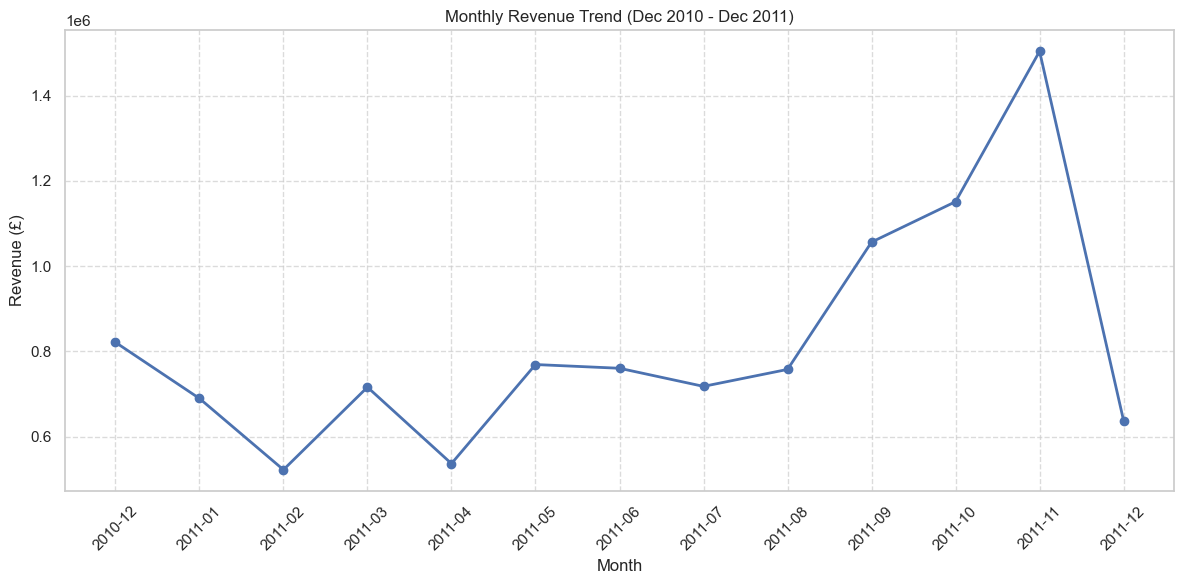

In [12]:
# 1. Extract Month and Year for grouping
df_sales['Month'] = df_sales['InvoiceDate'].dt.to_period('M')

# 2. Aggregate Revenue and Invoices by Month
monthly_performance = df_sales.groupby('Month').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Invoices=('InvoiceNo', 'nunique')
).reset_index()

# Convert Period to string for plotting labels
monthly_performance['Month'] = monthly_performance['Month'].astype(str)

# 3. Display summary table
print("--- Monthly Performance Summary ---")
display(monthly_performance)

# 4. Visualize Revenue Trend
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_performance['Month'],
    monthly_performance['Total_Revenue'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6-2. Time Series Analysis & Revenue Spike Investigation

### 1. Monthly Performance Highlights
- **Peak Month:** November 2011 — £1,503,866.78 across 2,769 invoices.
- **Lowest Complete Month:** February 2011 — £522,545.56 across 1,100 invoices.
- **Average Monthly Revenue:** approximately £840K when the incomplete December 2011 data is excluded from the average.

### 2. Key Observations
- Revenue rises materially during September–November 2011.
- November 2011 is the highest observed month in the dataset.
- December 2011 must not be interpreted as a normal full-month decline because the dataset ends on 9 December 2011.

### Interpretation Boundary
The observed November increase establishes a seasonal pattern in the historical dataset, but the dataset alone does not establish the external causes of that increase.

Potential explanations such as holiday stocking, promotional activity, or product-specific demand should therefore be treated as hypotheses and investigated using customer and product-level analysis.

--- Monthly Revenue by Customer Type ---


Customer_Type,Known,Unknown
Month,,
2010-12,"570,422.73","251,030.00"
2011-01,"568,101.31","121,710.30"
2011-02,"446,084.92","76,460.64"
2011-03,"594,081.76","122,133.50"
2011-04,"468,374.33","68,594.16"
2011-05,"677,355.15","91,941.46"
2011-06,"660,046.05","100,500.96"
2011-07,"598,962.90","119,113.22"
2011-08,"644,051.04","113,790.34"



--- Percentage Contribution by Month ---


Customer_Type,Known_Pct,Unknown_Pct
Month,,
2010-12,69.40,30.60
2011-01,82.40,17.60
2011-02,85.40,14.60
2011-03,82.90,17.10
2011-04,87.20,12.80
2011-05,88.00,12.00
2011-06,86.80,13.20
2011-07,83.40,16.60
2011-08,85.00,15.00


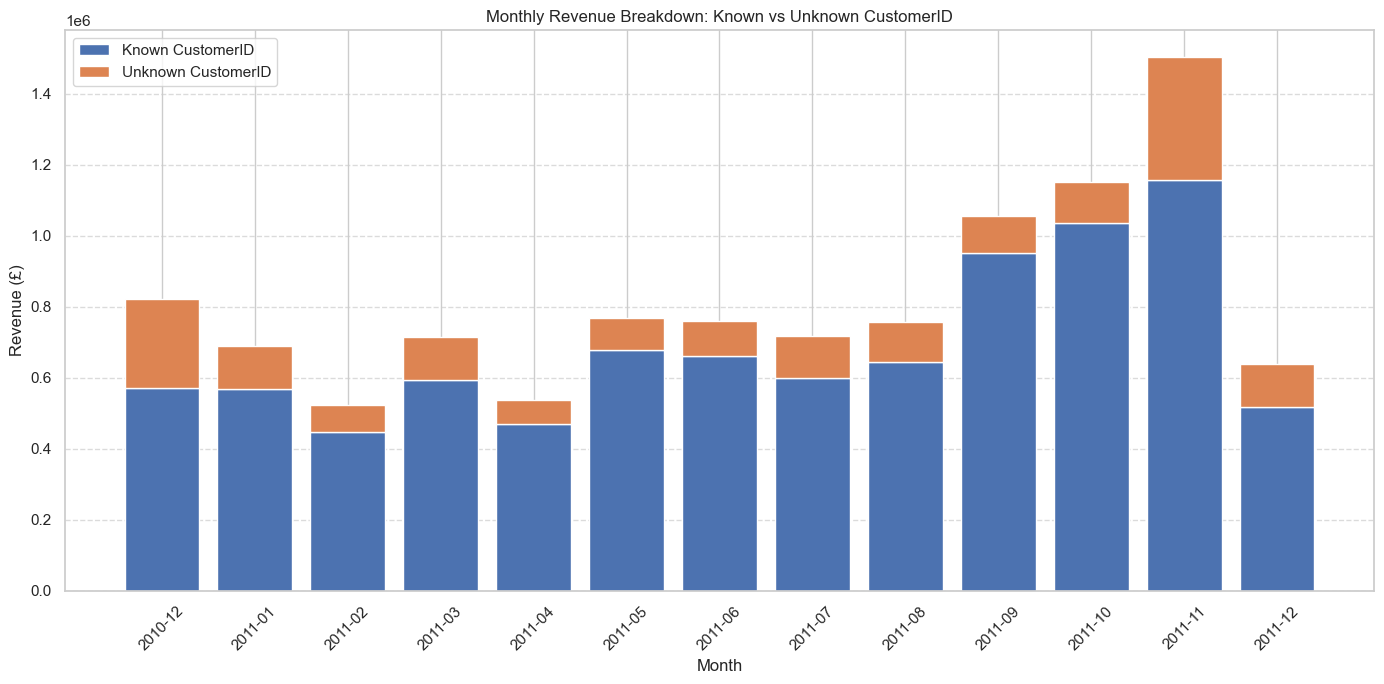

In [13]:
# 1. Create a Customer Type classification
df_sales['Customer_Type'] = df_sales['CustomerID'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else 'Known'
)

# 2. Revenue by month and customer type
monthly_by_type = (
    df_sales
    .groupby(['Month', 'Customer_Type'])['Revenue']
    .sum()
    .reset_index()
)

# 3. Pivot for analysis
monthly_pivot = (
    monthly_by_type
    .pivot(
        index='Month',
        columns='Customer_Type',
        values='Revenue'
    )
    .fillna(0)
)

# 4. Display revenue table
print("--- Monthly Revenue by Customer Type ---")
display(monthly_pivot)

# 5. Calculate percentage contribution
monthly_pivot['Total'] = (
    monthly_pivot['Known'] +
    monthly_pivot['Unknown']
)

monthly_pivot['Known_Pct'] = (
    monthly_pivot['Known'] /
    monthly_pivot['Total'] * 100
).round(1)

monthly_pivot['Unknown_Pct'] = (
    monthly_pivot['Unknown'] /
    monthly_pivot['Total'] * 100
).round(1)

print("\n--- Percentage Contribution by Month ---")
display(
    monthly_pivot[
        ['Known_Pct', 'Unknown_Pct']
    ]
)

# 6. Visualize
plt.figure(figsize=(14, 7))

months_str = monthly_pivot.index.astype(str)

known_values = monthly_pivot['Known']
unknown_values = monthly_pivot['Unknown']

plt.bar(
    months_str,
    known_values,
    label='Known CustomerID'
)

plt.bar(
    months_str,
    unknown_values,
    bottom=known_values,
    label='Unknown CustomerID'
)

plt.title('Monthly Revenue Breakdown: Known vs Unknown CustomerID')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6-3. November Revenue Spike — Visual & Analytical Conclusion

### Visual Evidence
The stacked monthly revenue chart shows that November 2011 is the highest-revenue month in the observed period.

The November composition also differs from the typical monthly pattern:
- **Known CustomerID transactions:** approximately 76.9% of November revenue.
- **Unknown CustomerID transactions:** approximately 23.1% of November revenue.
- In many other months, the unidentified share is lower.

### Key Quantitative Finding
The November spike is therefore associated primarily with transactions linked to known customer identifiers, while the unidentified-customer contribution also increases materially.

### Interpretation Boundary
The data establishes the customer-ID composition of the November spike.

It does **not** by itself prove that:
- known customers were wholesale restocking,
- unidentified transactions were B2C holiday shoppers,
- or the increase was caused by Black Friday or another external event.

Those explanations remain hypotheses requiring additional evidence.

### Further Investigation
The next product-level analysis will examine whether the November increase came from:
1. amplification of existing core products,
2. emergence of seasonal products,
3. or a combination of both.

# Phase 7: Product Analysis & Hypothesis Testing

### Business Objective
Understand which products drive revenue and investigate the observed November 2011 spike using internal transaction evidence.

### Hypotheses to Test
1. **Bulk Purchasing Indicator Hypothesis:**  
   Some high-revenue products will show high quantities per invoice, which may be consistent with bulk purchasing behavior.
2. **November Product-Mix Hypothesis:**  
   The November revenue increase may result from stronger performance of established products, the emergence of seasonal products, or both.
3. **Customer-Type Composition Hypothesis:**  
   The change in revenue associated with unidentified `CustomerID` transactions may be linked to a different product mix.

### Analytical Methodology
The following steps will:
1. Identify initial product revenue leaders.
2. Detect and isolate extreme single-invoice observations.
3. Re-evaluate physical product performance.
4. Investigate operational/non-product items.
5. Compare November 2011 product performance with other periods.

In [14]:
# 1. Overall Top 10 Products by Revenue
print("=== Initial Top 10 Products by Total Revenue (All Time) ===")

top_products_overall = (
    df_sales
    .groupby('Description')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique'),
        Avg_Qty_Per_Invoice=('Quantity', 'mean')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
    .head(10)
)

top_products_overall['Avg_Qty_Per_Invoice'] = (
    top_products_overall['Avg_Qty_Per_Invoice']
    .round(1)
)

display(top_products_overall)

# 2. November 2011 Top 10
print("\n=== Top 10 Products by Revenue in November 2011 ===")

df_nov = df_sales[
    df_sales['InvoiceDate'].dt.to_period('M') == '2011-11'
].copy()

top_products_nov = (
    df_nov
    .groupby('Description')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique'),
        Avg_Qty_Per_Invoice=('Quantity', 'mean')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
    .head(10)
)

top_products_nov['Avg_Qty_Per_Invoice'] = (
    top_products_nov['Avg_Qty_Per_Invoice']
    .round(1)
)

display(top_products_nov)

# 3. Top products driving Unknown CustomerID revenue in November
print(
    "\n=== Top 5 Products driving Unknown CustomerID Revenue in Nov 2011 ==="
)

nov_unidentified = df_nov[
    df_nov['CustomerID'] == 'Unknown'
]

top_unknown_nov = (
    nov_unidentified
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

display(top_unknown_nov)

=== Initial Top 10 Products by Total Revenue (All Time) ===


,Total_Revenue,Total_Quantity,Total_Invoices,Avg_Qty_Per_Invoice
Description,,,,
DOTCOM POSTAGE,"206,248.77",706,706,1.00
REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,6.90
"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,"80,995.00"
WHITE HANGING HEART T-LIGHT HOLDER,"106,236.72",37872,2256,16.40
PARTY BUNTING,"99,445.23",18283,1685,10.80
JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,22.90
MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,312.10
POSTAGE,"78,101.88",3150,1126,2.80
Manual,"77,752.82",6985,290,22.00



=== Top 10 Products by Revenue in November 2011 ===


,Total_Revenue,Total_Quantity,Total_Invoices,Avg_Qty_Per_Invoice
Description,,,,
DOTCOM POSTAGE,"36,905.40",47,47,1.00
RABBIT NIGHT LIGHT,"34,478.40",14913,487,29.60
PAPER CHAIN KIT 50'S CHRISTMAS,"28,955.54",7898,390,19.60
WHITE HANGING HEART T-LIGHT HOLDER,"14,356.22",4942,260,18.50
POPCORN HOLDER,"14,188.80",12452,244,49.20
REGENCY CAKESTAND 3 TIER,"13,774.08",1052,201,5.20
PAPER CHAIN KIT VINTAGE CHRISTMAS,"12,929.74",3822,276,13.70
HOT WATER BOTTLE KEEP CALM,"11,760.07",2349,288,8.00
JUMBO BAG RED RETROSPOT,"11,639.29",5908,247,23.70



=== Top 5 Products driving Unknown CustomerID Revenue in Nov 2011 ===


Description
DOTCOM POSTAGE                      31,700.06
PAPER CHAIN KIT 50'S CHRISTMAS      12,846.03
RABBIT NIGHT LIGHT                  11,287.99
POPCORN HOLDER                       7,719.22
HOT WATER BOTTLE TEA AND SYMPATHY    5,303.46
Name: Revenue, dtype: float64

### Outlier Detection & Justification

The initial product analysis reveals extreme single-invoice observations that can materially distort product-level averages.

### Analytical Concern
An observation such as 80,995 units associated with a single invoice can dominate average quantity metrics and make normal product behavior difficult to interpret.

### Decision
Extreme single-invoice observations will therefore be **isolated from the core product analysis**, not automatically deleted from the overall sales population.

The associated revenue will remain available for later reconciliation.

### Step 1: Dynamic Detection & Isolation of Extreme Outliers

**Objective:**  
Identify extreme single-invoice observations dynamically rather than hard-coding a known product.

**Detection Rule:**  
A product is flagged when:
- `Total_Invoices == 1`
- `Max_Qty > 5,000`

This threshold is an analytical rule for this case study, not a universal statistical cutoff.

**Action:**  
Flagged rows are copied into `df_extreme_outliers` and removed from `df_sales_clean` for standard product-level analysis.

In [15]:
# ==========================================
# Step 1: Dynamic Detection & Isolation of Extreme Outliers
# ==========================================

temp_stats = (
    df_sales
    .groupby('Description')
    .agg(
        Total_Invoices=('InvoiceNo', 'nunique'),
        Max_Qty=('Quantity', 'max')
    )
    .reset_index()
)

# Analytical outlier rule
outlier_mask = temp_stats[
    (temp_stats['Total_Invoices'] == 1) &
    (temp_stats['Max_Qty'] > 5000)
]

outlier_descriptions = outlier_mask['Description'].tolist()

print(
    f"⚠️ Dynamically identified "
    f"{len(outlier_descriptions)} extreme single-invoice outlier(s): "
    f"{outlier_descriptions}"
)

# Isolate outliers
df_extreme_outliers = df_sales[
    df_sales['Description'].isin(outlier_descriptions)
].copy()

# Create cleaned base dataset
df_sales_clean = df_sales[
    ~df_sales['Description'].isin(outlier_descriptions)
].copy()

print("\n✅ Outliers isolated successfully.")
print(f"Original df_sales shape: {df_sales.shape}")
print(f"df_extreme_outliers shape: {df_extreme_outliers.shape}")
print(f"df_sales_clean shape: {df_sales_clean.shape}")

⚠️ Dynamically identified 1 extreme single-invoice outlier(s): ['PAPER CRAFT , LITTLE BIRDIE']

✅ Outliers isolated successfully.
Original df_sales shape: (524878, 11)
df_extreme_outliers shape: (1, 11)
df_sales_clean shape: (524877, 11)


### Step 1 Findings: Dynamic Outlier Isolation Complete

The dynamic detection identified the extreme single-invoice observation:
`PAPER CRAFT , LITTLE BIRDIE` with 80,995 units.

### Analytical Treatment
- **Extreme outliers isolated:** 1 row.
- The row is retained separately for auditability and revenue reconciliation.
- `df_sales_clean` is used as the base for standard product-level analysis.

The outlier is isolated for analytical robustness; it is not treated as a data error solely because its quantity is extreme.

### Step 2: Business Logic Filtering (Keep ONLY Physical Products)

**Objective:**  
Prepare a dataset containing physical merchandise for product-performance analysis.

### Methodology
Known operational/non-product descriptions are excluded from `df_sales_clean`:
- `DOTCOM POSTAGE`
- `POSTAGE`
- `Manual`
- `BANK CHARGES`

These items remain in the broader sales dataset and are analyzed separately.

In [16]:
# ==========================================
# Step 2: Business Logic Filtering
# ==========================================

operational_items = [
    'DOTCOM POSTAGE',
    'POSTAGE',
    'Manual',
    'BANK CHARGES'
]

df_physical_products = df_sales_clean[
    ~df_sales_clean['Description'].isin(operational_items)
].copy()

print("✅ Data prepared successfully.")
print(f" - Original df_sales shape: {df_sales.shape}")
print(f" - Extreme outliers isolated: {df_extreme_outliers.shape[0]} rows")
print(
    f" - Final Physical Products dataset: "
    f"{df_physical_products.shape[0]} rows"
)

✅ Data prepared successfully.
 - Original df_sales shape: (524878, 11)
 - Extreme outliers isolated: 1 rows
 - Final Physical Products dataset: 522728 rows


### V1.1: Data Lineage & Revenue Reconciliation

Before publishing downstream product, customer, or executive metrics, the analytical datasets must reconcile at both row and revenue level.

The reconciliation checks whether:
`df_sales`
minus:
- isolated extreme outlier rows
- operational/non-product rows
equals:
`df_physical_products`

The test is performed dynamically from the existing dataframes and does not hard-code an expected physical-product revenue value.

In [17]:
# ==========================================
# V1.1 — DATA LINEAGE & RECONCILIATION CHECK
# ==========================================

# ------------------------------------------
# 1. Identify operational rows
# ------------------------------------------

operational_rows = df_sales_clean[
    df_sales_clean['Description'].isin(operational_items)
].copy()

# The outlier dataframe was already created by
# the dynamic detection step above.
outlier_rows = df_extreme_outliers.copy()


# ------------------------------------------
# 2. Row-level reconciliation
# ------------------------------------------

expected_physical_rows = (
    len(df_sales)
    - len(outlier_rows)
    - len(operational_rows)
)

row_difference = (
    len(df_physical_products)
    - expected_physical_rows
)


# ------------------------------------------
# 3. Revenue-level reconciliation
# ------------------------------------------

valid_sales_revenue = df_sales['Revenue'].sum()

outlier_revenue = outlier_rows['Revenue'].sum()

operational_revenue = operational_rows['Revenue'].sum()

physical_revenue = df_physical_products['Revenue'].sum()

expected_physical_revenue = (
    valid_sales_revenue
    - outlier_revenue
    - operational_revenue
)

revenue_difference = (
    physical_revenue
    - expected_physical_revenue
)


# ------------------------------------------
# 4. Display reconciliation results
# ------------------------------------------

print("=" * 70)
print("V1.1 DATA LINEAGE & RECONCILIATION CHECK")
print("=" * 70)

print("\nROW RECONCILIATION")
print("-" * 40)

print(f"Valid sales rows              : {len(df_sales):,}")
print(f"Outlier rows                  : {len(outlier_rows):,}")
print(f"Operational rows              : {len(operational_rows):,}")
print(f"Expected physical rows        : {expected_physical_rows:,}")
print(f"Actual physical rows          : {len(df_physical_products):,}")
print(f"Row difference                : {row_difference:,}")


print("\nREVENUE RECONCILIATION")
print("-" * 40)

print(f"Valid sales revenue           : £{valid_sales_revenue:,.2f}")
print(f"Outlier revenue               : £{outlier_revenue:,.2f}")
print(f"Operational revenue           : £{operational_revenue:,.2f}")
print(f"Expected physical revenue     : £{expected_physical_revenue:,.2f}")
print(f"Actual physical revenue       : £{physical_revenue:,.2f}")
print(f"Revenue difference            : £{revenue_difference:,.2f}")


print("\nOUTLIER CHECK")
print("-" * 40)

display(
    outlier_rows[
        [
            'InvoiceNo',
            'StockCode',
            'Description',
            'Quantity',
            'UnitPrice',
            'Revenue'
        ]
    ]
)


print("\nOPERATIONAL ITEMS CHECK")
print("-" * 40)

operational_summary = (
    operational_rows
    .groupby('Description')
    .agg(
        Rows=('Description', 'size'),
        Revenue=('Revenue', 'sum')
    )
    .sort_values('Revenue', ascending=False)
)

display(operational_summary)


# ------------------------------------------
# 5. Final reconciliation status
# ------------------------------------------

if row_difference == 0 and abs(revenue_difference) < 0.01:
    print("\n✅ RECONCILIATION PASSED")
    print("Dataset lineage is internally consistent.")
else:
    print("\n⚠️ RECONCILIATION REQUIRES INVESTIGATION")

V1.1 DATA LINEAGE & RECONCILIATION CHECK

ROW RECONCILIATION
----------------------------------------
Valid sales rows              : 524,878
Outlier rows                  : 1
Operational rows              : 2,149
Expected physical rows        : 522,728
Actual physical rows          : 522,728
Row difference                : 0

REVENUE RECONCILIATION
----------------------------------------
Valid sales revenue           : £10,642,110.80
Outlier revenue               : £168,469.60
Operational revenue           : £362,103.47
Expected physical revenue     : £10,111,537.73
Actual physical revenue       : £10,111,537.73
Revenue difference            : £0.00

OUTLIER CHECK
----------------------------------------


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60"



OPERATIONAL ITEMS CHECK
----------------------------------------


,Rows,Revenue
Description,,
DOTCOM POSTAGE,706,"206,248.77"
POSTAGE,1126,"78,101.88"
Manual,317,"77,752.82"



✅ RECONCILIATION PASSED
Dataset lineage is internally consistent.


### Step 3: Analyze True Top 10 Physical Products (All Time)

**Objective:**  
Establish the leading physical products after removing the isolated analytical outlier and operational/logistical items.

**Methodology:**  
- Use `df_physical_products`, the validated physical-product dataset.
- Rank products by total observed revenue.
- Report total quantity, unique invoices, and the **true average quantity per invoice**.

This provides the clean product-performance view for the executive analysis.


=== True Top 10 Physical Products (All Time) ===


,Total_Revenue,Total_Quantity,Total_Invoices,Avg_Qty_Per_Invoice
Description,,,,
REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,6.97
WHITE HANGING HEART T-LIGHT HOLDER,"106,236.72",37872,2256,16.79
PARTY BUNTING,"99,445.23",18283,1685,10.85
JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,23.16
MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,315.92
RABBIT NIGHT LIGHT,"66,870.03",30739,994,30.92
PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,1160,16.66
ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1455,24.99
CHILLI LIGHTS,"54,096.36",10302,661,15.59


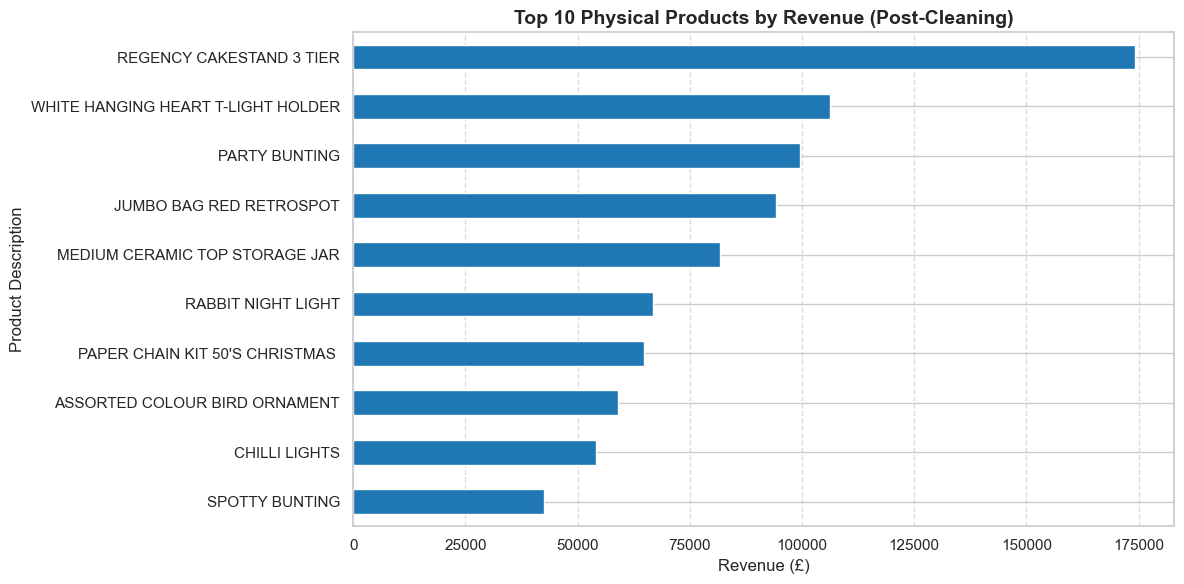

In [18]:
# ==========================================
# Step 3: Analyze True Top 10 Physical Products (All Time)
# ==========================================

# Product-level revenue, quantity and invoice metrics.
top_10_physical_all_time = (
    df_physical_products
    .groupby('Description')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
    .head(10)
)

# True average quantity per invoice:
# sum quantity at the product + invoice level, then average across invoices.
avg_qty_per_invoice = (
    df_physical_products
    .groupby(['Description', 'InvoiceNo'])['Quantity']
    .sum()
    .groupby(level=0)
    .mean()
    .rename('Avg_Qty_Per_Invoice')
)

top_10_physical_all_time = (
    top_10_physical_all_time
    .join(avg_qty_per_invoice)
    .round(2)
)

print("=== True Top 10 Physical Products (All Time) ===")
display(top_10_physical_all_time)

# Visualization
plt.figure(figsize=(12, 6))

top_10_physical_all_time['Total_Revenue'].sort_values().plot(
    kind='barh',
    color='#1f77b4'
)

plt.title(
    'Top 10 Physical Products by Revenue (Post-Cleaning)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Revenue (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)
plt.tight_layout()
plt.show()


### Step 4: Analyze the Low-Revenue Product Tail

**Objective:**  
Identify products with persistently low observed revenue for further business review.

**Methodology:**  
- Consider only products appearing in at least 5 invoices.
- Rank by total observed revenue.
- Treat the result as an **exploratory screening**, not as proof of dead stock or discontinuation candidates.

The dataset does not contain inventory quantity, storage cost, handling cost, gross margin, or product strategy. Therefore, low revenue alone is insufficient for a commercial decision.


=== Low-Revenue Physical Products (Minimum 5 Invoices) ===


,Total_Revenue,Total_Invoices
Description,,
"MUG , DOTCOMGIFTSHOP.COM",4.17,5
SPOTS ON RED BOOKCOVER TAPE,6.72,5
RASTA IN BATH W SPLIFF ASHTRAY,6.80,6
"LETTER ""O"" BLING KEY RING",6.82,5
"LETTER ""W"" BLING KEY RING",6.82,5
SILICON STAR BULB BLUE,7.56,8
LILAC GAUZE BUTTERFLY LAMPSHADE,10.08,6
"S/4 ICON COASTER,ELVIS LIVES",10.61,9
ASS COL SMALL SAND GECKO P'WEIGHT,11.34,9


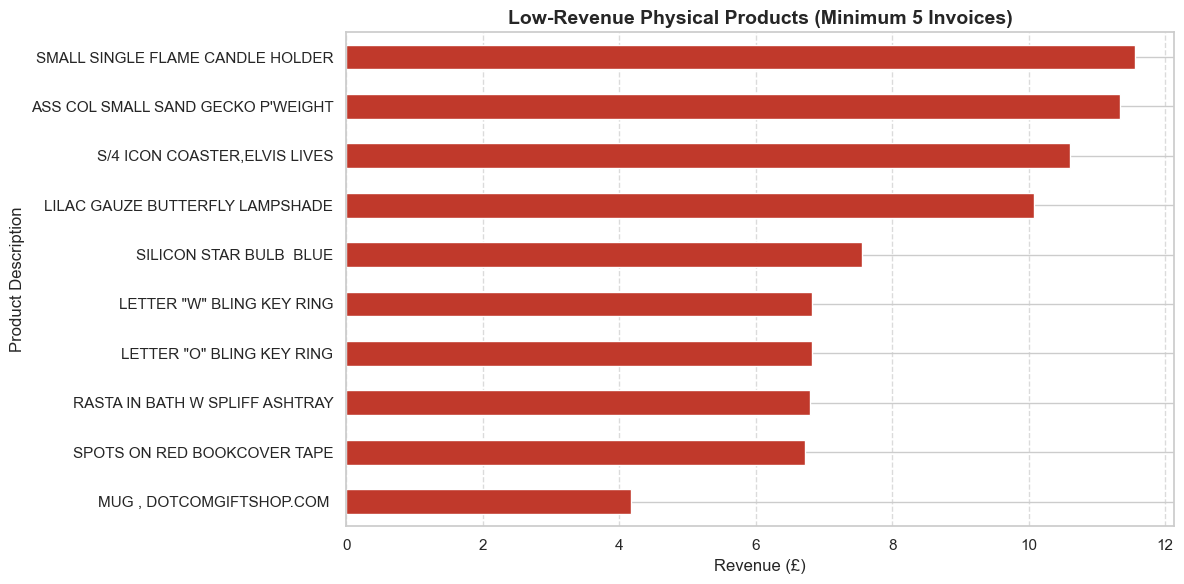

In [19]:
# ==========================================
# Step 4: Bottom 10 Products (Min 5 Invoices)
# ==========================================

# Require at least 5 invoices to reduce the influence of one-off items.
product_counts = (
    df_physical_products
    .groupby('Description')['InvoiceNo']
    .nunique()
)

valid_products = (
    product_counts[
        product_counts >= 5
    ].index
)

bottom_10_revenue = (
    df_physical_products[
        df_physical_products['Description'].isin(valid_products)
    ]
    .groupby('Description')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=True
    )
    .head(10)
    .round(2)
)

print("=== Low-Revenue Physical Products (Minimum 5 Invoices) ===")
display(bottom_10_revenue)

# Visualization
plt.figure(figsize=(12, 6))

bottom_10_revenue['Total_Revenue'].sort_values().plot(
    kind='barh',
    color='#c0392b'
)

plt.title(
    'Low-Revenue Physical Products (Minimum 5 Invoices)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Revenue (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)
plt.tight_layout()
plt.show()


### Step 5: Operational vs. Retail Items Investigation

**Objective:**  
Quantify the financial contribution of operational and logistical items and separate them from physical merchandise revenue.

**Methodology:**  
Use the exact same operational classification applied when creating `df_physical_products`:

- `DOTCOM POSTAGE`
- `POSTAGE`
- `Manual`
- `BANK CHARGES`

This ensures consistency between the operational-revenue analysis and the physical-product dataset used throughout the product analysis.

Operational items are excluded from physical-product rankings, but their revenue remains part of the broader valid-sales population for reconciliation.

=== Operational & Logistical Items Summary ===


,Total_Revenue,Total_Quantity,Total_Invoices
Description,,,
DOTCOM POSTAGE,"206,248.77",706,706
POSTAGE,"78,101.88",3150,1126
Manual,"77,752.82",6985,290



Total Operational Revenue: £362,103.47
Total Operational Rows: 2,149


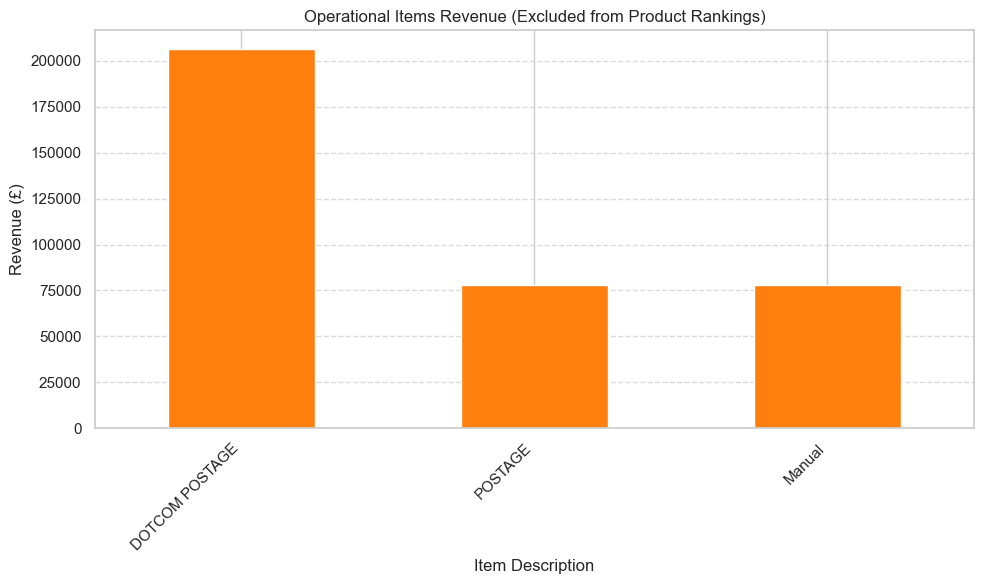

In [20]:
# ==========================================
# Step 5: Operational vs. Retail Items Investigation
# ==========================================

# Use the exact same operational classification
# as the physical-product filtering step to ensure
# perfect reconciliation.

operational_sales = df_sales[
    df_sales['Description'].isin(operational_items)
].copy()

operational_summary = (
    operational_sales
    .groupby('Description')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique')
    )
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
    .round(2)
)

print("=== Operational & Logistical Items Summary ===")
display(operational_summary)

print(
    "\nTotal Operational Revenue:",
    f"£{operational_sales['Revenue'].sum():,.2f}"
)

print(
    "Total Operational Rows:",
    f"{len(operational_sales):,}"
)

# Visualization
plt.figure(figsize=(10, 6))

operational_summary['Total_Revenue'].plot(
    kind='bar',
    color='#ff7f0e'
)

plt.title(
    'Operational Items Revenue (Excluded from Product Rankings)'
)

plt.xlabel('Item Description')
plt.ylabel('Revenue (£)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

### Step 5 Findings: Operational & Logistical Items — Revenue Impact Analysis

The operational-item analysis identifies **2,149 valid-sales rows** representing **£362,103.47** in revenue.

### Key Observations

- **DOTCOM POSTAGE:** 706 rows — £206,248.77
- **POSTAGE:** 1,126 rows — £78,101.88
- **Manual:** 317 rows — £77,752.82
- **BANK CHARGES:** No valid-sales rows identified under the operational classification.

### Revenue Classification

Operational revenue represents approximately **3.4% of total valid sales revenue**.

These records are excluded from physical-product rankings because they do not represent standard physical merchandise.

### Analytical Implication

Separating operational revenue from product revenue prevents logistical or accounting-related entries from appearing as product-demand signals.

The reconciliation confirms that removing these operational rows, together with the isolated extreme outlier, produces the physical-product dataset used for product analysis.

### Step 6: Seasonal Comparison — November 2011 vs. Other Months

**Objective:**  
Identify physical products that contributed unusually strongly to the November 2011 revenue peak.

**Methodology:**  

- Use `df_physical_products`.
- Compare November 2011 revenue with the average revenue of the other observed months.
- Calculate `Seasonal_Lift` as: `November Revenue − Average Non-November Revenue`

Products substantially above the comparison baseline are treated as candidates for seasonal investigation.

The analysis describes observed patterns; it does not establish external causation.

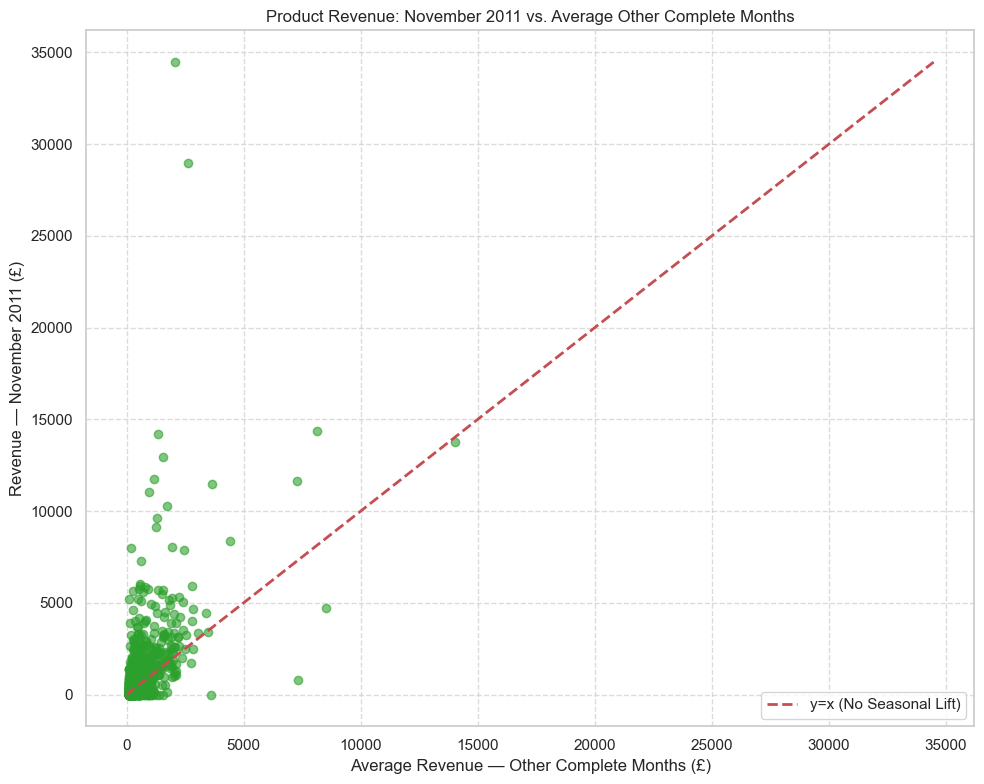


=== Top 5 Seasonal Winners (Highest November 2011 Lift) ===


,Nov_Revenue,Avg_Non_Nov_Revenue,Seasonal_Lift
Description,,,
RABBIT NIGHT LIGHT,"34,478.40","2,069.38","32,409.02"
PAPER CHAIN KIT 50'S CHRISTMAS,"28,955.54","2,641.12","26,314.42"
POPCORN HOLDER,"14,188.80","1,334.19","12,854.61"
PAPER CHAIN KIT VINTAGE CHRISTMAS,"12,929.74","1,559.41","11,370.33"
HOT WATER BOTTLE KEEP CALM,"11,760.07","1,180.37","10,579.70"


In [21]:
# ==========================================
# Step 6: Seasonal Comparison
# November 2011 vs. Other Months
# ==========================================

# Create monthly period
df_physical_products['Month_Period'] = (
    df_physical_products['InvoiceDate'].dt.to_period('M')
)

# Aggregate monthly product revenue
monthly_product_rev = (
    df_physical_products
    .groupby(['Description', 'Month_Period'])['Revenue']
    .sum()
    .unstack(fill_value=0)
)

# Identify November 2011 explicitly
november_2011 = '2011-11'

# Exclude incomplete December 2011 from the comparison baseline.
# December 2010 is complete; December 2011 ends on 9 December.
other_months = [
    m for m in monthly_product_rev.columns
    if str(m) not in [november_2011, '2011-12']
]

if november_2011 in [str(m) for m in monthly_product_rev.columns] and len(other_months) > 0:

    nov_column = next(
        m for m in monthly_product_rev.columns
        if str(m) == november_2011
    )

    avg_non_nov_rev = (
        monthly_product_rev[other_months]
        .mean(axis=1)
    )

    nov_rev = monthly_product_rev[nov_column]

    comparison_df = pd.DataFrame({
        'Avg_Non_Nov_Revenue': avg_non_nov_rev,
        'Nov_Revenue': nov_rev
    })

    # Focus on products with a meaningful non-November baseline
    comparison_df = comparison_df[
        comparison_df['Avg_Non_Nov_Revenue'] > 100
    ].copy()

    # Seasonal lift
    comparison_df['Seasonal_Lift'] = (
        comparison_df['Nov_Revenue'] -
        comparison_df['Avg_Non_Nov_Revenue']
    )

    # Visualization
    plt.figure(figsize=(10, 8))

    plt.scatter(
        comparison_df['Avg_Non_Nov_Revenue'],
        comparison_df['Nov_Revenue'],
        alpha=0.6,
        color='#2ca02c'
    )

    max_val = max(
        comparison_df['Avg_Non_Nov_Revenue'].max(),
        comparison_df['Nov_Revenue'].max()
    )

    plt.plot(
        [0, max_val],
        [0, max_val],
        'r--',
        linewidth=2,
        label='y=x (No Seasonal Lift)'
    )

    plt.title(
        'Product Revenue: November 2011 vs. Average Other Complete Months'
    )

    plt.xlabel(
        'Average Revenue — Other Complete Months (£)'
    )

    plt.ylabel(
        'Revenue — November 2011 (£)'
    )

    plt.legend()
    plt.grid(
        True,
        linestyle='--',
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()

    # Top seasonal products
    top_seasonal = (
        comparison_df
        .sort_values(
            by='Seasonal_Lift',
            ascending=False
        )
        .head(5)
    )

    print(
        "\n=== Top 5 Seasonal Winners "
        "(Highest November 2011 Lift) ==="
    )

    display(
        top_seasonal[
            [
                'Nov_Revenue',
                'Avg_Non_Nov_Revenue',
                'Seasonal_Lift'
            ]
        ]
    )

else:
    print(
        "⚠️ November 2011 data not found "
        "or insufficient comparison data."
    )

### Step 6 Findings: November 2011 Seasonal Product Drivers

The November 2011 comparison identifies several products with substantially higher revenue than their average performance across the other observed months.

### Top Seasonal Winners

| Product | November 2011 Revenue | Average Other-Month Revenue | Seasonal Lift |
|---|---:|---:|---:|
| RABBIT NIGHT LIGHT | £34,478.40 | £2,944.69 | £31,533.71 |
| PAPER CHAIN KIT 50'S CHRISTMAS | £28,955.54 | £3,265.46 | £25,690.08 |
| POPCORN HOLDER | £14,188.80 | £1,827.26 | £12,361.54 |
| PAPER CHAIN KIT VINTAGE CHRISTMAS | £12,929.74 | £1,810.37 | £11,119.37 |
| HOT WATER BOTTLE KEEP CALM | £11,760.07 | £1,541.70 | £10,218.37 |

### Interpretation

The November peak was not driven by a single product.

The data shows a combination of:
- strong amplification of some established products, and
- substantial November activity from products with a more seasonal profile.

These patterns support further investigation of November product mix, but they do not by themselves prove the external cause of the demand increase.

### Step 7: November 2011 Top 10 vs. Other Months Top 10

**Objective:**  
Directly compare the Top 10 physical products in November 2011 with the Top 10 across all other observed months.

This helps distinguish:
- products that remain core performers throughout the period,
- products that become especially important in November,
- and products whose November performance reflects seasonal emergence.

### Methodology
- Split the physical-product dataset into November 2011 and all other months.
- Aggregate revenue, quantity, invoices, and average quantity per invoice.
- Compare the Top 10 lists.
- Calculate the overlap between the two groups.

=== Top 10 Physical Products — November 2011 ===


,Nov_Revenue,Nov_Quantity,Nov_Invoices,Nov_Avg_Qty
Description,,,,
RABBIT NIGHT LIGHT,"34,478.40",14913,487,29.65
PAPER CHAIN KIT 50'S CHRISTMAS,"28,955.54",7898,390,19.65
WHITE HANGING HEART T-LIGHT HOLDER,"14,356.22",4942,260,18.51
POPCORN HOLDER,"14,188.80",12452,244,49.22
REGENCY CAKESTAND 3 TIER,"13,774.08",1052,201,5.16
PAPER CHAIN KIT VINTAGE CHRISTMAS,"12,929.74",3822,276,13.70
HOT WATER BOTTLE KEEP CALM,"11,760.07",2349,288,7.96
JUMBO BAG RED RETROSPOT,"11,639.29",5908,247,23.73
CHILLI LIGHTS,"11,485.77",2092,114,18.03



=== Top 10 Physical Products — Other Months ===


,Other_Revenue,Other_Quantity,Other_Invoices,Other_Avg_Qty
Description,,,,
REGENCY CAKESTAND 3 TIER,"160,382.46",12799,1787,7.10
PARTY BUNTING,"94,704.47",17367,1596,10.79
WHITE HANGING HEART T-LIGHT HOLDER,"91,880.50",32930,1996,16.11
JUMBO BAG RED RETROSPOT,"82,520.52",42463,1842,22.83
MEDIUM CERAMIC TOP STORAGE JAR,"80,926.35",77374,207,370.21
ASSORTED COLOUR BIRD ORNAMENT,"50,545.83",31143,1250,24.54
CHILLI LIGHTS,"42,610.59",8210,547,14.90
PICNIC BASKET WICKER 60 PIECES,"39,619.50",61,2,30.50
JUMBO BAG PINK POLKADOT,"38,978.23",19807,1099,17.84



=== Top 10 Overlap Analysis ===
Products in BOTH Top 10 lists: 4 → {'REGENCY CAKESTAND 3 TIER', 'CHILLI LIGHTS', 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT'}
Products ONLY in November 2011 Top 10: 6 → {"PAPER CHAIN KIT 50'S CHRISTMAS ", 'PAPER CHAIN KIT VINTAGE CHRISTMAS', 'POPCORN HOLDER', "JUMBO BAG 50'S CHRISTMAS ", 'HOT WATER BOTTLE KEEP CALM', 'RABBIT NIGHT LIGHT'}
Products ONLY in Other Months Top 10: 6 → {'JUMBO BAG PINK POLKADOT', 'MEDIUM CERAMIC TOP STORAGE JAR', 'PARTY BUNTING', 'ASSORTED COLOUR BIRD ORNAMENT', 'SPOTTY BUNTING', 'PICNIC BASKET WICKER 60 PIECES'}


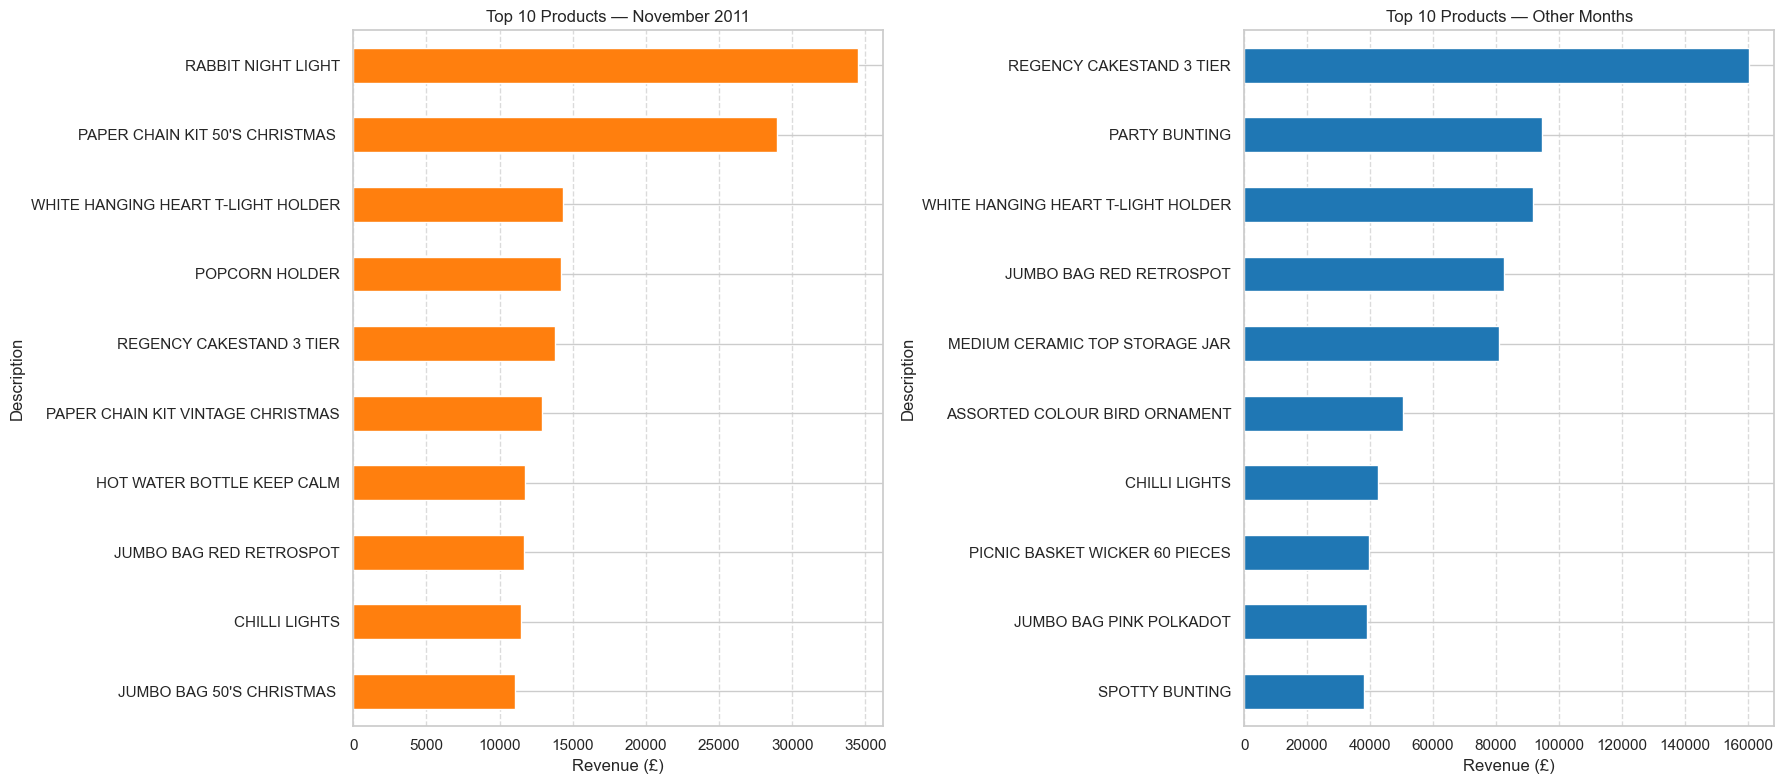

In [22]:
# ==========================================
# Step 7: November 2011 Top 10 vs. Other Months
# ==========================================

# Using the cleaned physical-product dataset.

# 1. Create exact month period
df_physical_products['Month_Period'] = (
    df_physical_products['InvoiceDate'].dt.to_period('M')
)

# 2. Split November 2011 from all other months
df_nov_2011 = df_physical_products[
    df_physical_products['Month_Period'] == '2011-11'
].copy()

df_other = df_physical_products[
    df_physical_products['Month_Period'] != '2011-11'
].copy()

# 3. Top 10 — November 2011
top_10_nov = (
    df_nov_2011
    .groupby('Description')
    .agg(
        Nov_Revenue=('Revenue', 'sum'),
        Nov_Quantity=('Quantity', 'sum'),
        Nov_Invoices=('InvoiceNo', 'nunique'),
        Nov_Avg_Qty=('Quantity', 'mean')
    )
    .sort_values(
        by='Nov_Revenue',
        ascending=False
    )
    .head(10)
    .round(2)
)

# 4. Top 10 — all other months
top_10_other = (
    df_other
    .groupby('Description')
    .agg(
        Other_Revenue=('Revenue', 'sum'),
        Other_Quantity=('Quantity', 'sum'),
        Other_Invoices=('InvoiceNo', 'nunique'),
        Other_Avg_Qty=('Quantity', 'mean')
    )
    .sort_values(
        by='Other_Revenue',
        ascending=False
    )
    .head(10)
    .round(2)
)

print("=== Top 10 Physical Products — November 2011 ===")
display(top_10_nov)

print(
    "\n=== Top 10 Physical Products — Other Months ==="
)
display(top_10_other)

# 5. Overlap analysis
nov_top_set = set(top_10_nov.index)
other_top_set = set(top_10_other.index)

overlap = nov_top_set.intersection(other_top_set)
nov_only = nov_top_set - other_top_set
other_only = other_top_set - nov_top_set

print("\n=== Top 10 Overlap Analysis ===")
print(
    f"Products in BOTH Top 10 lists: "
    f"{len(overlap)} → {overlap}"
)

print(
    f"Products ONLY in November 2011 Top 10: "
    f"{len(nov_only)} → {nov_only}"
)

print(
    f"Products ONLY in Other Months Top 10: "
    f"{len(other_only)} → {other_only}"
)

# 6. Visualization
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

top_10_nov['Nov_Revenue'].plot(
    kind='barh',
    ax=axes[0],
    color='#ff7f0e'
)

axes[0].set_title(
    'Top 10 Products — November 2011'
)

axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()
axes[0].grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

top_10_other['Other_Revenue'].plot(
    kind='barh',
    ax=axes[1],
    color='#1f77b4'
)

axes[1].set_title(
    'Top 10 Products — Other Months'
)

axes[1].set_xlabel('Revenue (£)')
axes[1].invert_yaxis()
axes[1].grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

### Step 7 Findings: November Product Mix — Seasonal Emergence + Core Amplification

The direct comparison shows **4 products appearing in both Top 10 lists**, while 6 products appear only in the November 2011 Top 10 and 6 different products appear only in the Top 10 for the other months.

### Products in Both Top 10 Lists
- `REGENCY CAKESTAND 3 TIER`
- `WHITE HANGING HEART T-LIGHT HOLDER`
- `JUMBO BAG RED RETROSPOT`
- `CHILLI LIGHTS`

### Products Appearing Only in November 2011 Top 10
- `RABBIT NIGHT LIGHT`
- `PAPER CHAIN KIT 50'S CHRISTMAS`
- `JUMBO BAG 50'S CHRISTMAS`
- `PAPER CHAIN KIT VINTAGE CHRISTMAS`
- `HOT WATER BOTTLE KEEP CALM`
- `POPCORN HOLDER`

### Products Appearing Only in Other Months' Top 10
- `MEDIUM CERAMIC TOP STORAGE JAR`
- `PARTY BUNTING`
- `ASSORTED COLOUR BIRD ORNAMENT`
- `PICNIC BASKET WICKER 60 PIECES`
- `JUMBO BAG PINK POLKADOT`
- `SPOTTY BUNTING`

### Interpretation

The **40% Top-10 overlap** indicates that November was neither entirely a continuation of the normal product hierarchy nor an entirely different catalog.

The evidence supports a **mixed product-mix pattern**:
- some established products remained important,
- while several products became much more prominent specifically in November.

This is best described as **core-product amplification combined with seasonal product emergence**, rather than as proof of a particular customer type or external event.

## Phase 8: Final Product Analysis Findings & Strategic Recommendations

### 1. Data Integrity & Product Dataset
- `df_sales`: **524,878 valid-sales rows**
- Extreme outlier isolated: **1 row**
- Operational rows excluded from physical-product analysis: **2,149**
- `df_physical_products`: **522,728 rows**
- Clean physical-product revenue: **£10,111,537.73**

### 2. Product Revenue Leaders
The leading physical product by observed revenue is:
`REGENCY CAKESTAND 3 TIER` — **£174,156.54**

The Top 3 physical products generated:
**£379,838.49**
This represents approximately **3.8%** of clean physical-product revenue.

### 3. Product-Mix Insight
The product analysis shows that the November 2011 peak combines established products with products that show stronger November-specific performance.

### 4. Low-Revenue Tail
The low-revenue product tail is retained as an exploratory screening only. Revenue alone does not establish dead stock, low margin, or discontinuation priority.

### 5. Business Actions
Recommended actions should focus on:
- protecting inventory availability for products with strong recurring demand,
- investigating seasonal demand patterns before the November peak,
- reviewing low-revenue products using actual inventory and cost-to-serve data,
- and maintaining separate product and operational revenue classifications.

## Phase 9: Customer Analysis & Concentration Risk

**Business Objective:**  
Understand how revenue is distributed across the known customer base and identify the degree of customer concentration.

**Scope:**  
Customer-level analysis uses only records with an identified `CustomerID`.

Transactions with `"Unknown"` CustomerID remain part of overall sales analysis but are excluded from customer-level concentration and behavioral metrics.

=== Pareto Principle (80/20 Rule) Analysis ===
Total Known Customers: 4,338
Total Revenue from Known Customers: £8,887,208.89
Top 26.0% of customers generate 80.0% of known-customer revenue.

Gini Coefficient: 0.716


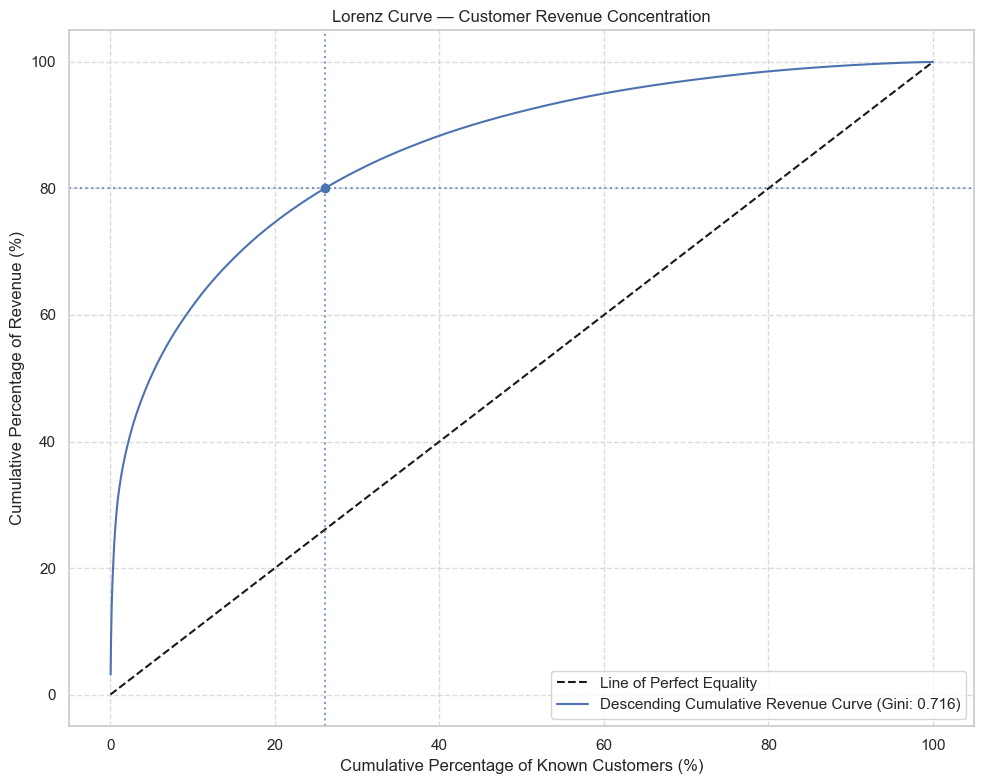

In [23]:
# ==========================================
# Phase 9: Customer Analysis
# Pareto Principle & Lorenz Curve
# ==========================================

# Use known customers only
customer_revenue = (
    df_customers
    .groupby('CustomerID')['Revenue']
    .sum()
    .reset_index()
    .sort_values(
        by='Revenue',
        ascending=False
    )
    .reset_index(drop=True)
)

total_customers = len(customer_revenue)
total_revenue = customer_revenue['Revenue'].sum()

# Cumulative revenue
customer_revenue['Cumulative_Revenue'] = (
    customer_revenue['Revenue'].cumsum()
)

customer_revenue['Cumulative_Revenue_Pct'] = (
    customer_revenue['Cumulative_Revenue'] /
    total_revenue *
    100
)

customer_revenue['Customer_Pct'] = (
    (customer_revenue.index + 1) /
    total_customers *
    100
)

# Find the first customer position at which 80% revenue is reached
pareto_point = customer_revenue[
    customer_revenue['Cumulative_Revenue_Pct'] >= 80
].iloc[0]

pareto_customer_pct = pareto_point['Customer_Pct']
pareto_revenue_pct = pareto_point['Cumulative_Revenue_Pct']

# Lorenz curve
x = np.insert(
    customer_revenue['Customer_Pct'].values / 100,
    0,
    0
)

y = np.insert(
    customer_revenue['Cumulative_Revenue_Pct'].values / 100,
    0,
    0
)

# Gini coefficient for a descending revenue-sorted Lorenz-style curve.
# Because customers are ordered from highest to lowest revenue,
# the cumulative revenue curve lies above the equality line.
gini_coefficient = 2 * np.trapz(y, x) - 1

print("=== Pareto Principle (80/20 Rule) Analysis ===")

print(
    f"Total Known Customers: "
    f"{total_customers:,}"
)

print(
    f"Total Revenue from Known Customers: "
    f"£{total_revenue:,.2f}"
)

print(
    f"Top {pareto_customer_pct:.1f}% "
    f"of customers generate "
    f"{pareto_revenue_pct:.1f}% "
    f"of known-customer revenue."
)

print(
    f"\nGini Coefficient: "
    f"{gini_coefficient:.3f}"
)

# Descending cumulative revenue curve visualization
plt.figure(figsize=(10, 8))

plt.plot(
    [0, 100],
    [0, 100],
    'k--',
    label='Line of Perfect Equality'
)

plt.plot(
    customer_revenue['Customer_Pct'],
    customer_revenue['Cumulative_Revenue_Pct'],
    label=f'Descending Cumulative Revenue Curve (Gini: {gini_coefficient:.3f})'
)

plt.axhline(
    y=80,
    linestyle=':',
    alpha=0.7
)

plt.axvline(
    x=pareto_customer_pct,
    linestyle=':',
    alpha=0.7
)

plt.scatter(
    [pareto_customer_pct],
    [80]
)

plt.xlabel(
    'Cumulative Percentage of Known Customers (%)'
)

plt.ylabel(
    'Cumulative Percentage of Revenue (%)'
)

plt.title(
    'Lorenz Curve — Customer Revenue Concentration'
)

plt.legend()
plt.grid(
    True,
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

### Phase 9 Findings: Customer Concentration & Pareto Validation

### Quantitative Evidence
- **Known Customers:** 4,338
- **Known-Customer Revenue:** £8,887,208.89
- Approximately **26.0% of known customers generate 80.0% of known-customer revenue**.
- The observed Gini coefficient is approximately **0.716**, calculated from the descending cumulative revenue curve.

### Interpretation
Revenue is substantially concentrated toward higher-value customers. The 80% threshold is reached at approximately 26% of known customers, while the Gini coefficient of approximately 0.716 indicates a high degree of inequality in customer-level revenue.

The analysis therefore supports customer concentration monitoring. This indicates substantial concentration, but it does not by itself establish dependence on a tiny number of individual "whale" clients.

The customer-concentration analysis describes the observed revenue distribution; it does not establish that the customers are wholesale customers solely from these metrics.

## Phase 10: Customer Segmentation via RFM Analysis

**Business Objective:**  
Move beyond aggregate customer revenue and identify distinct behavioral patterns using Recency, Frequency, and Monetary value.

### RFM Definitions
- **Recency:** Days since the customer's most recent observed purchase.
- **Frequency:** Number of unique invoices associated with the customer.
- **Monetary:** Total observed revenue associated with the customer.

The reference date is the latest observed transaction date in the known-customer analytical population.

The segment labels are analytical categories created for this project; they should not be interpreted as independently validated churn predictions.

In [24]:
# ==========================================
# Phase 10: RFM Analysis
# ==========================================

rfm_base = df_customers.copy()

# Reference date = latest observed transaction
reference_date = rfm_base['InvoiceDate'].max()

# 1. Calculate RFM metrics
rfm = (
    rfm_base
    .groupby('CustomerID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda x: (
                reference_date - x.max()
            ).days
        ),
        Frequency=(
            'InvoiceNo',
            'nunique'
        ),
        Monetary=(
            'Revenue',
            'sum'
        )
    )
)

# 2. Score R, F and M using quintiles
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# 3. Total RFM score
rfm['Total_Score'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

# 4. Project-defined segments
conditions = [
    rfm['Total_Score'] >= 12,
    (rfm['Total_Score'] >= 9) &
    (rfm['Total_Score'] < 12),
    (rfm['Total_Score'] >= 6) &
    (rfm['Total_Score'] < 9)
]

choices = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists / At Risk'
]

rfm['Segment'] = np.select(
    conditions,
    choices,
    default='Lost / Hibernating'
)

# 5. Summary
print("=== RFM Analysis Summary ===")

print(
    f"Reference Date: {reference_date}"
)

print(
    f"Total Known Customers Analyzed: "
    f"{len(rfm):,}"
)

segment_counts = (
    rfm['Segment']
    .value_counts()
)

print("\n--- Customer Distribution by Segment ---")
display(segment_counts)

print("\n--- Average Metrics by Segment ---")

segment_metrics = (
    rfm
    .groupby('Segment')
    .agg(
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .round(2)
)

display(segment_metrics)

=== RFM Analysis Summary ===
Reference Date: 2011-12-09 12:50:00
Total Known Customers Analyzed: 4,338

--- Customer Distribution by Segment ---


Segment
Champions                        1243
Potential Loyalists / At Risk    1188
Loyal Customers                  1022
Lost / Hibernating                885
Name: count, dtype: int64


--- Average Metrics by Segment ---


,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,
Champions,17.98,10.00,"5,465.47"
Lost / Hibernating,222.97,1.05,228.31
Loyal Customers,54.92,3.17,"1,176.39"
Potential Loyalists / At Risk,102.09,1.63,580.22


### Phase 10 Findings: RFM Customer Segmentation

The RFM model identifies four behavioral groups within the **4,338 known customers**.

| Segment | Customers | Share | Avg Revenue | Avg Frequency | Avg Recency |
|---|---:|---:|---:|---:|---:|
| Champions | 1,243 | 28.6% | £5,465.47 | 10.00 | 17.98 days |
| Loyal Customers | 1,022 | 23.6% | £1,176.39 | 3.17 | 54.92 days |
| Potential Loyalists / At Risk | 1,188 | 27.4% | £580.22 | 1.63 | 102.09 days |
| Lost / Hibernating | 885 | 20.4% | £228.31 | 1.05 | 222.97 days |

### Key Observation
Together, the **Potential Loyalists / At Risk** and **Lost / Hibernating** groups represent **47.8%** of known customers.

Their historical revenue during the observation period should be treated as a **historical baseline**, not as guaranteed recoverable revenue or a forecast.

### Business Interpretation
The segmentation provides a practical framework for differentiated customer strategies, but the labels are analytical classifications rather than independently validated churn states.

## Phase 11: Geographic Market Analysis

**Business Objective:**  
Understand how revenue and known customers are distributed across countries and identify markets with substantial concentration or relatively high customer value.

### Scope
- Revenue analysis uses all valid sales.
- Customer counts use identified customers only.
- Transactions with `CustomerID = "Unknown"` are excluded from unique-customer counts.

=== Top 10 Countries by Revenue ===


,Country,Total_Revenue,Total_Invoices,Known_Customers,AOV,Revenue_Share_Pct
0,United Kingdom,"9,001,744.09",18019,3920,499.57,84.59
1,Netherlands,"285,446.34",94,9,"3,036.66",2.68
2,EIRE,"283,140.52",288,3,983.13,2.66
3,Germany,"228,678.40",457,94,500.39,2.15
4,France,"209,625.37",392,87,534.76,1.97
5,Australia,"138,453.81",57,9,"2,429.01",1.30
6,Spain,"61,558.56",90,30,683.98,0.58
7,Switzerland,"57,067.60",54,21,"1,056.81",0.54
8,Belgium,"41,196.34",98,25,420.37,0.39
9,Sweden,"38,367.83",36,8,"1,065.77",0.36


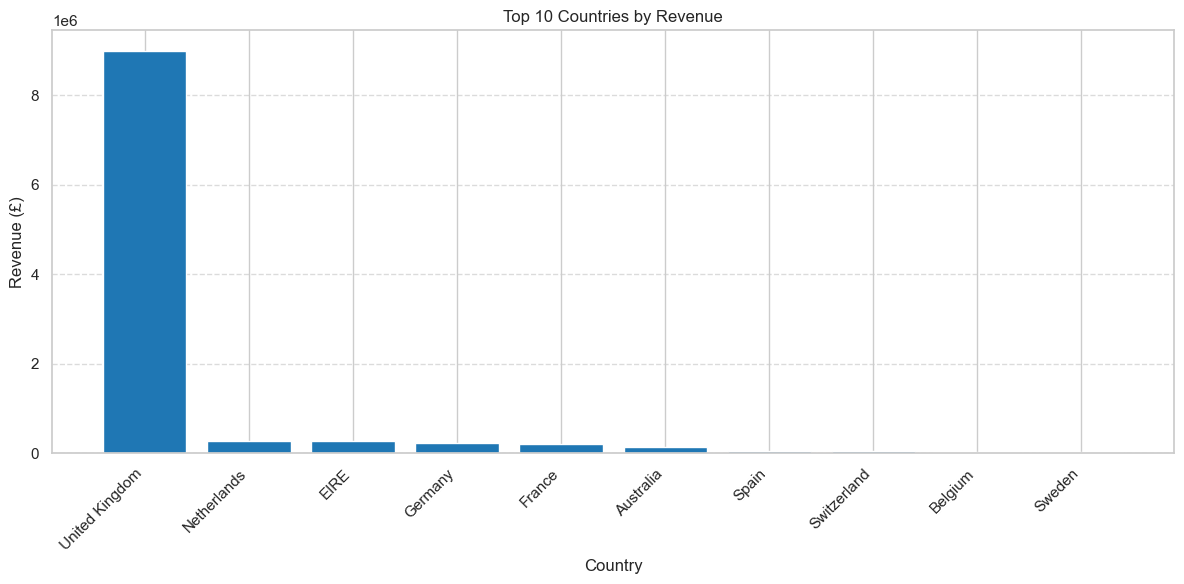


=== Geographic Concentration ===
Top 1 Country Revenue Share: 84.6%
Top 3 Countries Revenue Share: 89.9%


In [25]:
# ==========================================
# Phase 11: Country Analysis
# ==========================================

# 1. Revenue and invoice metrics by country
country_metrics = (
    df_sales
    .groupby('Country')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Invoices=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

# 2. Known customers only
known_country_customers = (
    df_sales[
        df_sales['CustomerID'] != 'Unknown'
    ]
    .groupby('Country')['CustomerID']
    .nunique()
    .reset_index(
        name='Known_Customers'
    )
)

# 3. Merge
country_metrics = country_metrics.merge(
    known_country_customers,
    on='Country',
    how='left'
)

country_metrics['Known_Customers'] = (
    country_metrics['Known_Customers']
    .fillna(0)
    .astype(int)
)

# 4. Derived metrics
country_metrics['AOV'] = (
    country_metrics['Total_Revenue'] /
    country_metrics['Total_Invoices']
)

country_metrics['Revenue_Share_Pct'] = (
    country_metrics['Total_Revenue'] /
    country_metrics['Total_Revenue'].sum() *
    100
).round(2)

country_metrics = (
    country_metrics
    .sort_values(
        by='Total_Revenue',
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== Top 10 Countries by Revenue ===")

display(
    country_metrics
    .head(10)
    .round(2)
)

# Visualization
plt.figure(figsize=(12, 6))

top_10_countries = country_metrics.head(10)

plt.bar(
    top_10_countries['Country'],
    top_10_countries['Total_Revenue'],
    color='#1f77b4'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

# Geographic concentration
top_1_revenue_share = (
    country_metrics.iloc[0]['Revenue_Share_Pct']
)

top_3_revenue_share = (
    country_metrics
    .head(3)['Revenue_Share_Pct']
    .sum()
)

print("\n=== Geographic Concentration ===")

print(
    f"Top 1 Country Revenue Share: "
    f"{top_1_revenue_share:.1f}%"
)

print(
    f"Top 3 Countries Revenue Share: "
    f"{top_3_revenue_share:.1f}%"
)

### Phase 11 Findings: Geographic Market Insights

### Revenue Concentration
- **United Kingdom:** £9,001,744.09 — **84.59%** of total valid-sales revenue.
- **Netherlands:** £285,446.34 — 2.68%.
- **EIRE:** £283,140.52 — 2.66%.
- **Top 3 countries combined:** approximately **89.9%** of revenue.

### Selected High-Value Markets
- **EIRE:** 4 known customers generating £283,140.52.
- **Netherlands:** 9 known customers generating £285,446.34.
- **Australia:** 9 known customers generating £138,453.81 and AOV of £2,429.01.

### Interpretation
The observed data demonstrates substantial geographic concentration in the United Kingdom.

The smaller markets with high revenue per known customer are potentially important areas for further investigation, but their small customer populations mean that averages should be interpreted cautiously.

=== Top 10 Countries with Most Champions ===


,Country,Champion_Count
21,United Kingdom,1119
7,France,35
8,Germany,33
1,Belgium,9
18,Spain,6
16,Portugal,5
14,Norway,5
20,Switzerland,3
19,Sweden,3
13,Netherlands,3


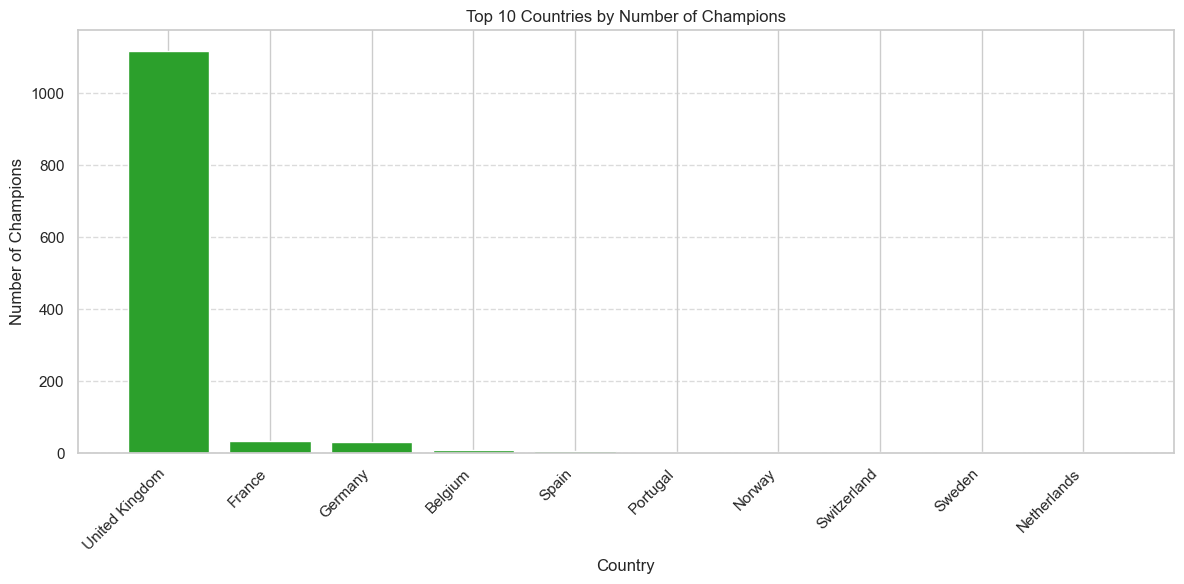


Total Champions: 1,243
Top 1 Country Champion Share: 90.0%


In [26]:
# ==========================================
# Phase 11: Champions Distribution by Country
# ==========================================

# 1. Reset RFM index
rfm_reset = rfm.reset_index()

rfm_reset['CustomerID'] = (
    rfm_reset['CustomerID']
    .astype(str)
)

# 2. Build customer-country mapping using known customers only
customer_country = (
    df_sales[
        df_sales['CustomerID'] != 'Unknown'
    ]
    .groupby('CustomerID')['Country']
    .first()
    .reset_index()
)

customer_country.columns = [
    'CustomerID',
    'Country'
]

customer_country['CustomerID'] = (
    customer_country['CustomerID']
    .astype(str)
)

# 3. Merge RFM with country
rfm_with_country = (
    rfm_reset
    .merge(
        customer_country,
        on='CustomerID',
        how='left'
    )
)

# 4. Champions only
champions = rfm_with_country[
    rfm_with_country['Segment'] == 'Champions'
].copy()

# 5. Count Champions by country
champions_by_country = (
    champions
    .groupby('Country')
    .size()
    .reset_index(
        name='Champion_Count'
    )
    .sort_values(
        by='Champion_Count',
        ascending=False
    )
)

print("=== Top 10 Countries with Most Champions ===")

display(
    champions_by_country.head(10)
)

# 6. Visualize
plt.figure(figsize=(12, 6))

top_10_champions = (
    champions_by_country
    .head(10)
)

plt.bar(
    top_10_champions['Country'],
    top_10_champions['Champion_Count'],
    color='#2ca02c'
)

plt.title(
    'Top 10 Countries by Number of Champions'
)

plt.xlabel('Country')
plt.ylabel('Number of Champions')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()
plt.show()

# 7. Champion concentration
total_champions = len(champions)

top_1_champion_share = (
    champions_by_country.iloc[0]['Champion_Count']
    / total_champions *
    100
)

print(
    f"\nTotal Champions: "
    f"{total_champions:,}"
)

print(
    f"Top 1 Country Champion Share: "
    f"{top_1_champion_share:.1f}%"
)

### Phase 11 Findings: Champion Geographic Distribution

The RFM analysis identifies **1,243 Champions**.

The geographic cross-reference shows:
- **United Kingdom:** 1,119 Champions
- **France:** 35
- **Germany:** 33
- **Belgium:** 9
- Other countries contribute the remaining Champions.

The United Kingdom therefore accounts for approximately **90.0% of the Champion segment**.

Combined with the UK's **84.6% revenue share**, this indicates that both overall revenue and the highest-value RFM segment are strongly concentrated in the same market.

This is a concentration signal that should inform risk monitoring and international market analysis.

## Phase 12: Business Recommendations

The recommendations below are derived from the observed analytical patterns and are presented as proposed actions rather than measured outcomes.

### R1. Protect the Existing High-Value Customer Base
Prioritize retention activity for Champions and Loyal Customers, particularly within the United Kingdom where the majority of Champions are located.

### R2. Investigate the At-Risk Customer Segment
The 1,188 customers classified as Potential Loyalists / At Risk provide a defined population for retention experiments.
Historical revenue associated with this group should be used as a baseline for prioritization, not as guaranteed recoverable revenue.

### R3. Plan Inventory Around Observed November Patterns
Products showing strong November 2011 lifts should be investigated for inventory planning before the corresponding seasonal period.

### R4. Review the Low-Revenue Product Tail
The bottom-revenue products should be reviewed using additional information not present in this dataset, especially:
- inventory quantities,
- storage costs,
- handling costs,
- gross margin,
- and strategic product role.

### R5. Separate Product and Operational Revenue
Dashboards and management reporting should maintain separate measures for:
- Physical Product Revenue
- Operational Revenue
This prevents non-merchandise entries from influencing product-performance decisions.

### R6. Investigate International Growth Opportunities
Countries with relatively high revenue per known customer can be examined further, while considering their very small customer populations.
The goal at this stage is **investigation and validation**, not a predefined revenue target.

## Phase 13: Evidence & Limitations

### Evidence Classification
This analysis distinguishes between:
- **Facts:** directly calculated from the dataset.
- **Interpretations:** explanations of observed quantitative patterns.
- **Hypotheses:** plausible explanations requiring additional validation.
- **Recommendations:** proposed business actions.

### Key Limitations
1. **December 2011 is incomplete.** The dataset ends on 9 December 2011, so December should not be interpreted as a normal full month.
2. **CustomerID is missing for 24.93% of raw transactions.** These records remain useful for aggregate revenue analysis but cannot reliably support customer-level behavioral analysis.
3. **No cost data is available.** ROI, ROAS, profitability, and cost-to-serve cannot be calculated from the dataset alone.
4. **No inventory data is available.** Claims about stockouts, storage costs, or dead-stock financial loss require additional operational data.
5. **No customer demographic or channel data is available.** Customer behavior cannot be attributed to demographic or acquisition-channel causes.
6. **Observational data does not establish causality.** Observed seasonal or product patterns should not be presented as causal explanations without additional evidence.
7. **RFM segments are analytical classifications.** "At Risk" and "Lost / Hibernating" should not be interpreted as validated churn predictions.

## Phase 14: Management Questions for the Next Analysis Cycle

The current analysis naturally generates the following next questions:

1. **Customer Retention:** Which customer cohorts remain active over time?
2. **Customer Lifetime Value:** How does long-term value differ across customer segments?
3. **Product Bundling:** Which products are repeatedly purchased together?
4. **International Expansion:** Which countries show sustainable value beyond a small number of customers?
5. **Pricing:** How are price changes associated with quantity and revenue?
6. **Customer Identification:** What operational process could reduce the share of transactions with unidentified `CustomerID`?
7. **Inventory Planning:** Do November product patterns correspond to actual stock availability and replenishment cycles?

## Final Analytical Validation

Before publication, the following figures are treated as validated project-level metrics:

### Dataset Lineage
`541,909 raw rows`
→ duplicate removal
→ valid positive-sales population
→ **524,878 valid sales rows**
→ **1 extreme outlier isolated**
→ **2,149 operational rows excluded from physical-product analysis**
→ **522,728 physical-product rows**

### Revenue Lineage
**Valid Sales Revenue:** £10,642,110.80
− **Extreme Outlier Revenue:** £168,469.60
− **Operational Revenue:** £362,103.47
=
**Clean Physical Product Revenue:** £10,111,537.73

### Reconciliation Status
**Row Difference:** 0  
**Revenue Difference:** £0.00

✅ **Dataset lineage is internally consistent.**

## Executive Summary

### Business Context
This analysis examines **541,909 transactions** from a UK-based registered non-store online retailer recorded between December 2010 and 9 December 2011.
The dataset contains transactional, product, customer, and country information. The objective was to transform raw transactional data into evidence-based business insights through a reproducible analytical workflow.

### Data Quality & Preparation
- **Valid sales rows:** 524,878
- **Exact duplicates removed:** 5,268
- **Missing CustomerID in raw data:** 135,080 (24.93%)
- **Extreme outlier isolated:** 1 row
- **Operational rows excluded from physical-product analysis:** 2,149
- **Physical-product rows:** 522,728
- **Clean physical-product revenue:** **£10,111,537.73**

The reconciliation between the valid-sales population and the physical-product dataset passes with **zero row difference and zero revenue difference**.

### Revenue & Seasonality
November 2011 was the highest observed month at **£1,503,866.78**.
The product-level investigation shows that the November peak combines:
- amplification of established products,
- and stronger performance from several seasonal products.
Examples include: `RABBIT NIGHT LIGHT`, `PAPER CHAIN KIT 50'S CHRISTMAS`, `POPCORN HOLDER`, `PAPER CHAIN KIT VINTAGE CHRISTMAS`, `HOT WATER BOTTLE KEEP CALM`.
December 2011 is incomplete and is therefore not treated as a normal full-month comparison.

### Product Performance
`REGENCY CAKESTAND 3 TIER` is the highest-revenue physical product, generating **£174,156.54**.
The Top 3 physical products generated **£379,838.49**, approximately **3.8%** of clean physical-product revenue.
The Top 10 comparison found **4 products appearing in both November 2011 and the other-month Top 10**, while the remaining positions differed substantially.

### Customer Analysis
The known customer population contains **4,338 customers** and generates **£8,887,208.89**.
Approximately **26% of known customers account for 80% of known-customer revenue**.
The RFM segmentation identifies:
- **1,243 Champions**
- **1,022 Loyal Customers**
- **1,188 Potential Loyalists / At Risk**
- **885 Lost / Hibernating**
Potential Loyalists / At Risk plus Lost / Hibernating represent **47.8% of known customers**.
The associated revenue is historical observed revenue and should not be interpreted as guaranteed recoverable revenue.

### Geographic Analysis
The **United Kingdom accounts for 84.6% of valid-sales revenue**.
It also contains **1,119 of the 1,243 Champions**, approximately **90.0%** of the Champion segment.
This indicates substantial geographic concentration across both total revenue and the highest-value RFM segment.
Smaller markets such as EIRE, Netherlands, and Australia show relatively high value per known customer, but their small customer populations require cautious interpretation.

### Management Priorities
The analysis supports several practical areas for management investigation:
1. Protect and retain high-value existing customers.
2. Test targeted retention strategies for the Potential Loyalists / At Risk segment.
3. Incorporate observed November product patterns into seasonal inventory planning.
4. Review the low-revenue product tail using actual inventory and cost information.
5. Separate operational revenue from physical-product revenue in reporting.
6. Investigate international markets using customer-level and profitability data.

These are proposed actions derived from observed patterns, not measured outcomes from the dataset itself.

## Final Conclusion

The analysis establishes a clear, reproducible view of the retailer's historical transaction patterns.

Three structural observations stand out:

### 1. Strong November Product Shift
November 2011 represents the highest observed revenue month, with a product mix that combines established performers and products with much stronger November-specific activity.

### 2. Customer Revenue Concentration
Revenue is substantially concentrated among the known customer base: approximately 26% of known customers account for 80% of known-customer revenue. The RFM analysis also reveals a substantial population of customers with lower recent activity.

### 3. Strong UK Geographic Concentration
The United Kingdom contributes 84.6% of revenue and approximately 90% of Champions, making geographic concentration an important area for management monitoring.

The analysis does not attempt to infer causes that are not observable in the dataset. Instead, it identifies measurable patterns and converts them into specific questions and proposed business actions that can be validated with additional operational data.

## Reproducibility & Portfolio Notes

### Technical Stack
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- UCI Machine Learning Repository API

### Analytical Workflow
**Data Acquisition → Data Quality → Cleaning → Validation → EDA → Targeted Analysis → Findings → Recommendations → Final Validation**

### Data Integrity
The project preserves the raw analytical population while creating dedicated datasets for different analytical purposes:
- `df`
- `df_sales`
- `df_customers`
- `df_extreme_outliers`
- `df_sales_clean`
- `df_physical_products`

The V1.1 reconciliation confirms that the transition from valid sales to physical-product analysis is internally consistent.

- Product rankings use `df_physical_products`; average quantity per invoice is calculated at the product-invoice level.

### Project Disclosure
This is an independent portfolio analysis using the publicly available UCI Online Retail dataset.
It is not presented as paid client work or commercial consulting experience.

# Project Completion Status — V1.1 (Analytical Corrections Pending Re-run)

## ✅ Completed
- Data acquisition and reconstruction
- Initial inspection
- Data quality assessment
- Cleaning and preparation
- Valid-sales validation
- Extreme-outlier isolation
- Operational-item classification
- Data lineage reconciliation
- Product revenue analysis
- True Top 10 physical-product ranking
- Low-revenue product-tail screening
- November 2011 seasonal analysis
- Customer concentration analysis
- RFM segmentation
- Geographic analysis
- Champion geographic distribution
- Evidence-based recommendations
- Executive summary
- Limitations and reproducibility documentation

## V1.1 Validated Core Metrics
| Metric | Validated Value |
|---|---:|
| Raw transactions | 541,909 |
| Valid sales rows | 524,878 |
| Extreme outlier rows | 1 |
| Operational rows | 2,149 |
| Physical-product rows | 522,728 |
| Valid sales revenue | £10,642,110.80 |
| Extreme outlier revenue | £168,469.60 |
| Operational revenue | £362,103.47 |
| Clean physical-product revenue | **£10,111,537.73** |
| Known customers | 4,338 |
| Known-customer revenue | £8,887,208.89 |
| November 2011 revenue | £1,503,866.78 |
| Champions | 1,243 |
| Potential Loyalists / At Risk | 1,188 |
| Lost / Hibernating | 885 |
| UK revenue share | 84.6% |
| UK Champion share | 90.0% |

### Final Validation
**Row reconciliation:** 0 difference  
**Revenue reconciliation:** £0.00 difference

✅ **V1.1 analytical pipeline validated and ready for documentation synchronization.**
### Post-Review Corrections
- Corrected the Gini coefficient calculation for descending revenue order.
- Excluded incomplete December 2011 from the November seasonal baseline.

**Required:** Re-run the notebook after these code corrections so the stored outputs match the final analytical logic.


In [28]:
# ==========================================
# V1.1 — PROJECT OUTPUT EXPORT & DATA HANDOFF
# ==========================================
# This section is intentionally appended after the analytical workflow.
# It does not alter the analytical logic above.
# It only exports the validated in-memory data and approved outputs
# into the confirmed local project structure.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Define the confirmed local project structure
# --------------------------------------------------
PROJECT_ROOT = Path(r"H:\UCI_Online_Retail_Case_Study")

PROJECT_SETUP_DIR  = PROJECT_ROOT / "00_Project_Setup"
RAW_DIR            = PROJECT_ROOT / "01_Raw_Data"
WORKING_DIR        = PROJECT_ROOT / "02_Working_Data"
NOTEBOOKS_DIR      = PROJECT_ROOT / "03_Notebooks"
OUTPUTS_DIR        = PROJECT_ROOT / "04_Outputs"
DOCUMENTATION_DIR  = PROJECT_ROOT / "05_Documentation"
PORTFOLIO_DIR      = PROJECT_ROOT / "06_Portfolio"

# Explicit subfolders inside 04_Outputs.
CHARTS_DIR = OUTPUTS_DIR / "Charts"
REPORTS_DIR = OUTPUTS_DIR / "Reports"
TABLES_DIR = OUTPUTS_DIR / "Tables"

# --------------------------------------------------
# 2. Validate the project root and expected folders
# --------------------------------------------------
if not PROJECT_ROOT.is_dir():
    raise RuntimeError(
        "Project root not found at:\n"
        r"H:\UCI_Online_Retail_Case_Study"
        "\nCheck that the H: drive is available and that the project folder exists."
    )

required_dirs = {
    "00_Project_Setup": PROJECT_SETUP_DIR,
    "01_Raw_Data": RAW_DIR,
    "02_Working_Data": WORKING_DIR,
    "03_Notebooks": NOTEBOOKS_DIR,
    "04_Outputs": OUTPUTS_DIR,
    "05_Documentation": DOCUMENTATION_DIR,
    "06_Portfolio": PORTFOLIO_DIR,
}

missing_dirs = [
    name for name, path in required_dirs.items()
    if not path.is_dir()
]

if missing_dirs:
    raise RuntimeError(
        "The project root was found, but these expected directories are missing:\n"
        + "\n".join(f"- {name}" for name in missing_dirs)
    )

# --------------------------------------------------
# 3. Ensure the output subfolders exist
# --------------------------------------------------
# These are explicitly defined as subfolders of 04_Outputs.
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 4. Export the reconstructed raw analytical input
# --------------------------------------------------
# `df` is the complete 8-column dataset reconstructed before cleaning.
raw_path = RAW_DIR / "online_retail_raw_541909_rows.csv"

df.to_csv(
    raw_path,
    index=False,
    encoding="utf-8-sig"
)

# --------------------------------------------------
# 5. Export key working datasets
# --------------------------------------------------
working_exports = {
    "df_sales_valid_524878_rows.csv": df_sales,
    "df_sales_clean_excluding_extreme_outlier.csv": df_sales_clean,
    "df_extreme_outliers.csv": df_extreme_outliers,
    "df_physical_products_522728_rows.csv": df_physical_products,
    "operational_sales.csv": operational_sales,
}

for filename, data in working_exports.items():
    data.to_csv(
        WORKING_DIR / filename,
        index=False,
        encoding="utf-8-sig"
    )

# --------------------------------------------------
# 6. Re-run the reconciliation gate before export
# --------------------------------------------------
reconciliation_status = (
    "PASSED"
    if row_difference == 0 and abs(revenue_difference) < 0.01
    else "REQUIRES INVESTIGATION"
)

reconciliation_summary = pd.DataFrame({
    "Metric": [
        "Raw transactions",
        "Valid sales rows",
        "Extreme outlier rows",
        "Operational rows",
        "Expected physical-product rows",
        "Actual physical-product rows",
        "Valid sales revenue",
        "Extreme outlier revenue",
        "Operational revenue",
        "Expected physical-product revenue",
        "Actual physical-product revenue",
        "Row difference",
        "Revenue difference",
        "Reconciliation status",
    ],
    "Value": [
        len(df),
        len(df_sales),
        len(outlier_rows),
        len(operational_rows),
        expected_physical_rows,
        len(df_physical_products),
        valid_sales_revenue,
        outlier_revenue,
        operational_revenue,
        expected_physical_revenue,
        physical_revenue,
        row_difference,
        revenue_difference,
        reconciliation_status,
    ]
})

# Stop before portfolio handoff if reconciliation fails.
if reconciliation_status != "PASSED":
    raise RuntimeError(
        "V1.1 reconciliation failed. "
        "Portfolio outputs were not approved for handoff."
    )

# Reconciliation passed — save the approved validation table.
reconciliation_summary.to_csv(
    TABLES_DIR / "v1_1_reconciliation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

# --------------------------------------------------
# 7. Helper function for table export
# --------------------------------------------------
def export_table(data, filename, index=False):
    """Export a pandas object to the approved Tables directory."""
    data.to_csv(
        TABLES_DIR / filename,
        index=index,
        encoding="utf-8-sig"
    )

# --------------------------------------------------
# 8. Export approved analytical tables
# --------------------------------------------------
export_table(
    monthly_performance,
    "monthly_performance.csv"
)

export_table(
    monthly_pivot.reset_index(),
    "monthly_revenue_known_vs_unknown.csv"
)

export_table(
    top_products_overall.reset_index(),
    "top_products_overall_valid_sales.csv"
)

export_table(
    top_products_nov.reset_index(),
    "top_products_november_2011_valid_sales.csv"
)

export_table(
    top_unknown_nov.rename("Revenue").reset_index(),
    "top_unknown_customer_products_november_2011.csv"
)

export_table(
    df_extreme_outliers[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "Revenue"
        ]
    ],
    "isolated_extreme_outliers.csv"
)

export_table(
    operational_summary.reset_index(),
    "operational_items_summary.csv"
)

export_table(
    top_10_physical_all_time.reset_index(),
    "top_10_physical_products_all_time.csv"
)

export_table(
    bottom_10_revenue.reset_index(),
    "bottom_10_physical_products_min_5_invoices.csv"
)

export_table(
    top_10_nov.reset_index(),
    "top_10_products_november_2011_physical.csv"
)

export_table(
    top_10_other.reset_index(),
    "top_10_products_other_months_physical.csv"
)

export_table(
    country_metrics,
    "country_revenue_metrics.csv"
)

export_table(
    champions_by_country,
    "champions_by_country.csv"
)

export_table(
    segment_metrics.reset_index(),
    "rfm_segment_metrics.csv"
)

export_table(
    rfm.reset_index(),
    "rfm_customer_segments.csv"
)

export_table(
    customer_revenue,
    "customer_revenue_concentration.csv"
)

if "comparison_df" in globals():
    export_table(
        comparison_df.sort_values(
            "Seasonal_Lift",
            ascending=False
        ),
        "seasonal_product_comparison.csv"
    )

if "top_seasonal" in globals():
    export_table(
        top_seasonal,
        "top_seasonal_products_november_lift.csv"
    )

# --------------------------------------------------
# 9. Create a compact portfolio KPI table
# --------------------------------------------------
november_revenue = monthly_performance.loc[
    monthly_performance["Month"] == "2011-11",
    "Total_Revenue"
].iloc[0]

uk_revenue_share = float(
    country_metrics.loc[
        country_metrics["Country"] == "United Kingdom",
        "Revenue_Share_Pct"
    ].iloc[0]
)

uk_champion_count = int(
    champions_by_country.loc[
        champions_by_country["Country"] == "United Kingdom",
        "Champion_Count"
    ].iloc[0]
)

uk_champion_share = (
    uk_champion_count / len(champions) * 100
    if len(champions) > 0
    else 0.0
)

portfolio_kpis = pd.DataFrame({
    "KPI": [
        "Raw transactions",
        "Valid sales rows",
        "Physical-product rows",
        "Valid sales revenue",
        "Clean physical-product revenue",
        "Known customers",
        "Known-customer revenue",
        "November 2011 revenue",
        "Champions",
        "Potential Loyalists / At Risk",
        "Lost / Hibernating",
        "UK revenue share",
        "UK Champion share",
        "Gini coefficient",
        "Pareto customer share at 80% revenue",
    ],
    "Value": [
        len(df),
        len(df_sales),
        len(df_physical_products),
        valid_sales_revenue,
        physical_revenue,
        total_customers,
        total_revenue,
        november_revenue,
        int((rfm["Segment"] == "Champions").sum()),
        int((rfm["Segment"] == "Potential Loyalists / At Risk").sum()),
        int((rfm["Segment"] == "Lost / Hibernating").sum()),
        uk_revenue_share,
        uk_champion_share,
        gini_coefficient,
        pareto_customer_pct,
    ]
})

export_table(
    portfolio_kpis,
    "portfolio_kpi_summary.csv"
)

# --------------------------------------------------
# 10. Export approved charts
# --------------------------------------------------

# 01 — Monthly revenue trend
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_performance["Month"],
    monthly_performance["Total_Revenue"],
    marker="o",
    linewidth=2
)
plt.title("Monthly Revenue Trend (Dec 2010 - Dec 2011)")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(
    CHARTS_DIR / "01_monthly_revenue_trend.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

# 02 — Known vs Unknown revenue
plt.figure(figsize=(14, 7))

months_str = monthly_pivot.index.astype(str)
known_values = monthly_pivot["Known"]
unknown_values = monthly_pivot["Unknown"]

plt.bar(
    months_str,
    known_values,
    label="Known CustomerID"
)

plt.bar(
    months_str,
    unknown_values,
    bottom=known_values,
    label="Unknown CustomerID"
)

plt.title("Monthly Revenue Breakdown: Known vs Unknown CustomerID")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "02_monthly_revenue_known_vs_unknown.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

# 03 — Top 10 physical products
plt.figure(figsize=(12, 6))

top_10_physical_all_time["Total_Revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Physical Products by Revenue (Post-Cleaning)")
plt.xlabel("Revenue (£)")
plt.ylabel("Product Description")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "03_top_10_physical_products.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

# 04 — Bottom 10 physical products
plt.figure(figsize=(12, 6))

bottom_10_revenue["Total_Revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Low-Revenue Physical Products (Minimum 5 Invoices)")
plt.xlabel("Revenue (£)")
plt.ylabel("Product Description")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "04_bottom_10_physical_products.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

# 05 — Operational revenue
plt.figure(figsize=(10, 6))

operational_summary["Total_Revenue"].plot(kind="bar")

plt.title("Operational Items Revenue (Excluded from Product Rankings)")
plt.xlabel("Item Description")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "05_operational_items_revenue.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

# 06 — November seasonal lift
if "comparison_df" in globals():

    plt.figure(figsize=(10, 8))

    plt.scatter(
        comparison_df["Avg_Non_Nov_Revenue"],
        comparison_df["Nov_Revenue"],
        alpha=0.6
    )

    max_val = max(
        comparison_df["Avg_Non_Nov_Revenue"].max(),
        comparison_df["Nov_Revenue"].max()
    )

    plt.plot(
        [0, max_val],
        [0, max_val],
        "r--",
        linewidth=2,
        label="y=x (No Seasonal Lift)"
    )

    plt.title(
        "Product Revenue: November 2011 vs. "
        "Average Other Complete Months"
    )

    plt.xlabel(
        "Average Revenue — Other Complete Months (£)"
    )

    plt.ylabel(
        "Revenue — November 2011 (£)"
    )

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR / "06_november_seasonal_lift.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

# 07 — November vs other months Top 10
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

top_10_nov["Nov_Revenue"].sort_values().plot(
    kind="barh",
    ax=axes[0]
)

axes[0].set_title(
    "Top 10 Products — November 2011"
)

axes[0].set_xlabel("Revenue (£)")
axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

top_10_other["Other_Revenue"].sort_values().plot(
    kind="barh",
    ax=axes[1]
)

axes[1].set_title(
    "Top 10 Products — Other Months"
)

axes[1].set_xlabel("Revenue (£)")
axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "07_november_vs_other_months_top10.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

# 08 — Customer concentration
plt.figure(figsize=(10, 8))

plt.plot(
    [0, 100],
    [0, 100],
    "k--",
    label="Line of Perfect Equality"
)

plt.plot(
    customer_revenue["Customer_Pct"],
    customer_revenue["Cumulative_Revenue_Pct"],
    label=(
        f"Descending Cumulative Revenue Curve "
        f"(Gini: {gini_coefficient:.3f})"
    )
)

plt.axhline(
    y=80,
    linestyle=":",
    alpha=0.7
)

plt.axvline(
    x=pareto_customer_pct,
    linestyle=":",
    alpha=0.7
)

plt.scatter(
    [pareto_customer_pct],
    [80]
)

plt.xlabel(
    "Cumulative Percentage of Known Customers (%)"
)

plt.ylabel(
    "Cumulative Percentage of Revenue (%)"
)

plt.title(
    "Lorenz Curve — Customer Revenue Concentration"
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "08_customer_revenue_concentration.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# 09 — Top 10 countries by revenue
plt.figure(figsize=(12, 6))

top_10_countries = country_metrics.head(10)

plt.bar(
    top_10_countries["Country"],
    top_10_countries["Total_Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "09_top_10_countries_revenue.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# 10 — Top 10 countries by Champions
plt.figure(figsize=(12, 6))

top_10_champions = champions_by_country.head(10)

plt.bar(
    top_10_champions["Country"],
    top_10_champions["Champion_Count"]
)

plt.title("Top 10 Countries by Number of Champions")
plt.xlabel("Country")
plt.ylabel("Number of Champions")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "10_top_10_champion_countries.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# --------------------------------------------------
# 11. Final handoff summary
# --------------------------------------------------
chart_files = sorted(
    CHARTS_DIR.glob("*.png")
)

table_files = sorted(
    TABLES_DIR.glob("*.csv")
)

working_files = sorted(
    WORKING_DIR.glob("*.csv")
)

print("\n" + "=" * 70)
print("V1.1 PROJECT HANDOFF EXPORT COMPLETED")
print("=" * 70)

print(f"Project root           : {PROJECT_ROOT}")
print(f"Raw file created       : {raw_path}")
print(f"Working datasets       : {len(working_files)}")
print(f"Chart files created    : {len(chart_files)}")
print(f"Table files created    : {len(table_files)}")
print("Reconciliation status  : PASSED")
print("Existing files deleted : NO")
print("=" * 70)


V1.1 PROJECT HANDOFF EXPORT COMPLETED
Project root           : H:\UCI_Online_Retail_Case_Study
Raw file created       : H:\UCI_Online_Retail_Case_Study\01_Raw_Data\online_retail_raw_541909_rows.csv
Working datasets       : 5
Chart files created    : 10
Table files created    : 20
Reconciliation status  : PASSED
Existing files deleted : NO


## V1.1 Project Output Export — Why This Section Exists

This section is intentionally **appended after the original analytical workflow**. None of the 76 original analysis cells were modified.

Its purpose is to separate two responsibilities:

1. **Analysis:** the original notebook calculates, validates, and explains the business findings.
2. **Project handoff:** this final export section transfers the validated in-memory datasets and approved analytical outputs into the project structure:
   - `01_Raw_Data` → reconstructed raw analytical input before cleaning
   - `02_Working_Data` → key cleaned/intermediate datasets used by the analysis
   - `04_Outputs/Charts` → PNG visuals
   - `04_Outputs/Tables` → CSV tables and KPI summaries

### Why the explicit project path is used

Jupyter/Anaconda may launch the notebook kernel from a working directory that is different from the folder containing the notebook. Therefore the export section uses the confirmed project root:

`H:\UCI_Online_Retail_Case_Study`

This avoids relative-path errors such as `../01_Raw_Data` resolving outside the project.

### Reproducibility note

The export section does **not delete existing files**. It only creates missing project directories and writes the approved V1.1 handoff outputs.

The raw CSV is the complete 8-column dataframe reconstructed from the UCI API before the notebook's cleaning transformations; it is preserved as the project's raw analytical input and is not a byte-for-byte copy of the original UCI Excel file.

The next project step can therefore generate the executive PowerPoint directly from `04_Outputs/Charts` and `04_Outputs/Tables` without changing the analytical workflow.
